# **Project Name**    - Hospital Length of Stay Prediction (PRCP-1022-HospitalStayPred)

##### **Project Type**    - Classification (Ordinal Multi-Class)
##### **Contribution**    - Individual
##### **Team Member -** Yaswanth Gunda

# **Project Summary -**

This project analyzes hospital admission data to predict a patient's length of stay at the time of admission, a task with direct operational value for healthcare resource planning. The dataset contains approximately 318,000 patient admission records spanning 18 features, including hospital attributes (type, region, department, ward, bed grade), patient attributes (age, city, severity of illness), and admission details (type of admission, number of visitors, admission deposit). The target variable, length of stay, is provided as 11 bucketed ranges from "0-10 days" to "More than 100 Days."

The project began with a thorough exploratory data analysis covering univariate, bivariate, and multivariate relationships across 15 visualizations, following the UBM structure. During this process, a significant data quality issue was uncovered: a hidden Excel auto-date-conversion bug had silently corrupted the "11-20" category into "20-Nov" in both the Stay and Age columns, which was identified and corrected before further analysis. Additional data preparation included mode imputation for two columns with minor missingness (Bed_Grade and City_Code_Patient), IQR-based outlier capping for Admission_Deposit and Visitors_with_Patient, and a combination of ordinal, label, and one-hot encoding strategies tailored to each categorical feature's underlying structure.

Three hypotheses were formally tested using Chi-Square and Kruskal-Wallis tests, all confirming statistically significant relationships: Severity of Illness, Age, and Department each significantly affect Length of Stay. Notably, a raw count-based chart initially suggested Severity had little effect on Stay, but normalizing the same data by percentage revealed a clear pattern that the raw view had obscured — a useful reminder to normalize before comparing distributions across imbalanced groups.

Feature engineering included multicollinearity checks (removing two redundant one-hot encoded pairs), Random Forest-based feature importance for feature selection, skewness correction via log transformation, and standard scaling for potential use with scale-sensitive models. Given a significant class imbalance in the target (a 31.89:1 ratio between the largest and smallest classes), class weighting was applied during model training rather than synthetic resampling, to avoid generating potentially unrealistic synthetic patient profiles across 11 overlapping ordinal categories.

Three models were built and compared: Logistic Regression (baseline), Random Forest, and XGBoost, each tuned via cross-validated hyperparameter search. Logistic Regression significantly underperformed the tree-based models and showed no improvement from tuning, confirming that the relationship between features and target — particularly for Admission_Deposit, which ranked as the top predictor despite near-zero linear correlation with the target — is fundamentally non-linear. Random Forest ultimately outperformed XGBoost, achieving the best weighted F1-score (0.3618) and accuracy (36.71%), and was selected as the final model for its balanced performance across classes and its interpretable feature importance output.

While overall predictive performance reflects the genuine difficulty of this imbalanced, 11-class ordinal problem, the final model provides meaningful, actionable signal for identifying likely long-stay patients at admission time — supporting proactive bed allocation, staffing, and discharge planning in a real hospital setting.

# **GitHub Link -**

https://github.com/yaswanth0068/hospital-length-of-stay-prediction

# **Problem Statement**


This project addresses two tasks defined for the PRCP-1022-HospitalStayPred capstone: (1) preparing a complete data analysis report on hospital admission data, and (2) building a machine learning model to predict a patient's length of stay (in days) at the time of hospital admission, using factors such as hospital type, department, ward, bed grade, patient severity of illness, age, number of visitors, and admission deposit. The dataset is provided by the project brief (sourced from an AV Healthcare Analytics dataset) and falls within the Healthcare domain. Deliverables include a Model Comparison Report evaluating multiple models and recommending the best one for production, and a Challenges Report documenting data issues encountered and the techniques used to address them — all consolidated within a single Jupyter notebook.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
# Importing core libraries for data handling
import pandas as pd
import numpy as np

# Importing libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Importing libraries for statistical tests (will be used later in hypothesis testing)
import scipy.stats as stats

# Importing libraries for machine learning - will be used later in modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Setting a default style for our plots so charts look consistent throughout the notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Suppressing unnecessary warnings so the notebook output stays clean
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


### Dataset Loading

In [2]:
# Load Dataset

# Loading the hospital stay dataset
# Using a try-except here so we get a clear message if the file path/name is wrong,
# instead of a raw FileNotFoundError traceback
try:
    df = pd.read_csv("HealthCareAnalytics.csv")
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("File not found. Please check that HealthCareAnalytics.csv is in the same folder as this notebook.")

Dataset loaded successfully!


### Dataset First View

In [3]:
# Dataset First Look

# Taking a quick look at the first few rows to understand the structure of the data
df.head()

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count

# Checking how many rows (patient records) and columns (features) we're working with
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 318438
Number of columns: 18


### Dataset Information

In [5]:
# Dataset Info

# Getting data types and non-null counts for every column in one shot
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital_code                      318438 non-null  int64  
 2   Hospital_type_code                 318438 non-null  str    
 3   City_Code_Hospital                 318438 non-null  int64  
 4   Hospital_region_code               318438 non-null  str    
 5   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  str    
 7   Ward_Type                          318438 non-null  str    
 8   Ward_Facility_Code                 318438 non-null  str    
 9   Bed_Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  313906 non-null

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count

# Checking if there are any fully duplicated rows in the dataset
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count

# Checking how many missing values each column has, sorted from highest to lowest
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values)

City_Code_Patient                    4532
Bed_Grade                             113
Hospital_code                           0
case_id                                 0
Hospital_region_code                    0
Hospital_type_code                      0
Available_Extra_Rooms_in_Hospital       0
Department                              0
Ward_Type                               0
City_Code_Hospital                      0
Ward_Facility_Code                      0
patientid                               0
Type_of_Admission                       0
Severity_of_Illness                     0
Visitors_with_Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64


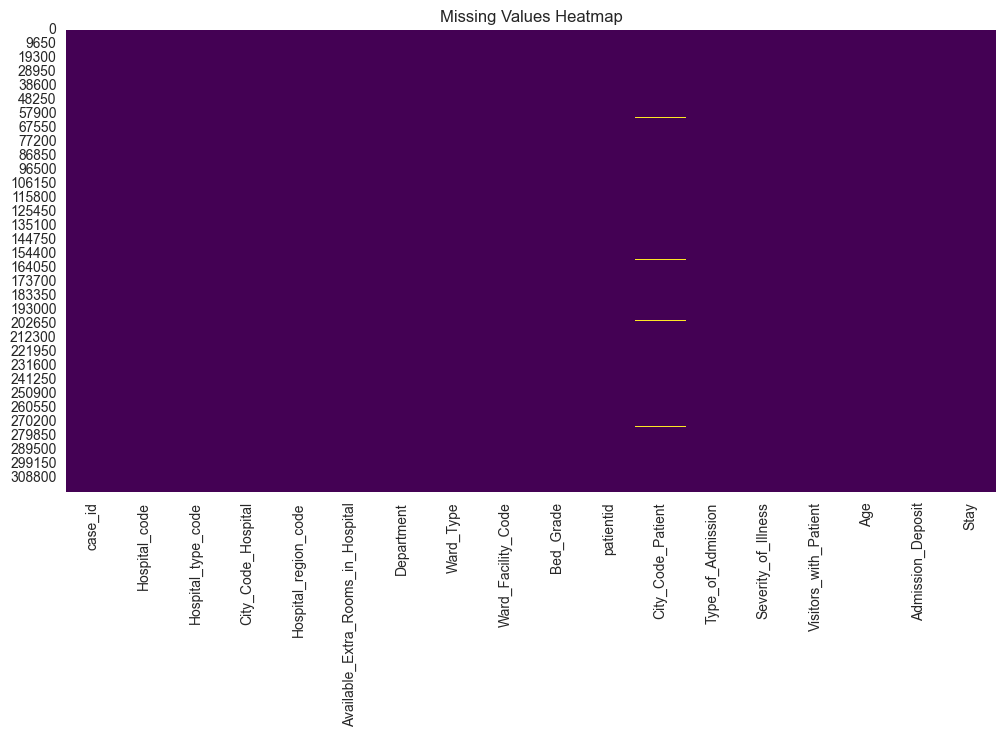

In [8]:
# Visualizing the missing values

# Visualizing missing values as a heatmap - makes it easy to spot which columns
# have gaps and whether the missingness has any pattern
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains 318,438 patient admission records across 18 columns, with no duplicate rows, which is a good sign for data quality. Out of the 18 columns, 9 are categorical/object type (Hospital_type_code, Hospital_region_code, Department, Ward_Type, Ward_Facility_Code, Type_of_Admission, Severity_of_Illness, Age, and our target column Stay), 7 are integer type (mostly ID/count columns like case_id, Hospital_code, patientid, Visitors_with_Patient, Admission_Deposit), and 2 are float type (Bed_Grade and City_Code_Patient) which have missing values.

Two columns have missing values — City_Code_Patient (4,532 missing, ~1.4%) and Bed_Grade (113 missing, ~0.03%) — both relatively small in proportion to the dataset size, so we won't need to drop rows; imputation should work fine here.

The target variable Stay is a categorical column represented as ranges (e.g., "0-10", "41-50"), not a continuous number — meaning even though the problem statement calls it a regression task ("predict length of stay in days"), the raw data is actually binned/bucketed. We'll need to decide how to handle this during Data Wrangling (either treat it as an ordinal classification problem, or convert bins to numeric estimates for true regression) — a key design decision we'll revisit in Section 3.

Also worth noting: case_id and patientid are identifier columns and won't carry predictive value — they'll likely be dropped later. City_Code_Patient and Bed_Grade, despite being float64, are actually categorical/ordinal codes, not continuous measurements.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns

# Listing out all column names for quick reference
df.columns

Index(['case_id', 'Hospital_code', 'Hospital_type_code', 'City_Code_Hospital',
       'Hospital_region_code', 'Available_Extra_Rooms_in_Hospital',
       'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed_Grade',
       'patientid', 'City_Code_Patient', 'Type_of_Admission',
       'Severity_of_Illness', 'Visitors_with_Patient', 'Age',
       'Admission_Deposit', 'Stay'],
      dtype='str')

In [10]:
# Dataset Describe

# Getting summary statistics for numerical columns - helps spot ranges, outliers, and scale differences
df.describe()

,case_id,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Visitors_with_Patient,Admission_Deposit
count,318438.000000,318438.000000,318438.000000,318438.000000,318325.000000,318438.000000,313906.000000,318438.000000,318438.000000
mean,159219.500000,18.318841,4.771717,3.197627,2.625807,65747.579472,7.251859,3.284099,4880.749392
std,91925.276848,8.633755,3.102535,1.168171,0.873146,37979.936440,4.745266,1.764061,1086.776254
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1800.000000
25%,79610.250000,11.000000,2.000000,2.000000,2.000000,32847.000000,4.000000,2.000000,4186.000000
50%,159219.500000,19.000000,5.000000,3.000000,3.000000,65724.500000,8.000000,3.000000,4741.000000
75%,238828.750000,26.000000,7.000000,4.000000,3.000000,98470.000000,8.000000,4.000000,5409.000000
max,318438.000000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,11008.000000


In [11]:
# Also checking summary stats for categorical columns - shows unique count, top category, and its frequency
df.describe(include='object')

,Hospital_type_code,Hospital_region_code,Department,Ward_Type,Ward_Facility_Code,Type_of_Admission,Severity_of_Illness,Age,Stay
count,318438,318438,318438,318438,318438,318438,318438,318438,318438
unique,7,3,5,6,6,3,3,10,11
top,a,X,gynecology,R,F,Trauma,Moderate,41-50,21-30
freq,143425,133336,249486,127947,112753,152261,175843,63749,87491


### Variables Description

The dataset has 18 columns covering hospital-side attributes, patient-side attributes, and the target. Here's a quick breakdown:

Identifiers (no predictive value): case_id (fully unique, 318,438 values), patientid (92,017 unique — meaning many patients have multiple admission records in this dataset).

Hospital attributes: Hospital_code (32 hospitals), Hospital_type_code (7 types, coded a–g), City_Code_Hospital (11 cities), Hospital_region_code (3 regions: X, Y, Z), Available_Extra_Rooms_in_Hospital (0–24 rooms, right-skewed — most values cluster around 2–4), Department (5 departments, gynecology is most frequent), Ward_Type (6 types), Ward_Facility_Code (6 codes), Bed_Grade (ordinal, 1–4, mostly 2–3).

Patient/admission attributes: City_Code_Patient (37 cities), Type_of_Admission (3 categories: Trauma, Emergency, Urgent — Trauma most common), Severity_of_Illness (3 levels: Minor, Moderate, Extreme — Moderate most common), Visitors_with_Patient (0–32, right-skewed), Age (10 bucketed ranges, e.g. "51-60"), Admission_Deposit (continuous, ₹1,800–₹11,008, roughly normal-ish around ₹4,880).

Target: Stay — 11 bucketed categories (e.g. "0-10", "21-30", up to what's likely "More than 100 Days"), most common bucket is "21-30" days.

A key observation: several numeric-looking columns (Bed_Grade, City_Code_Hospital, City_Code_Patient) are actually categorical/ordinal codes, not measurements — so they'll need to be treated as categorical during encoding, not scaled as continuous numbers.

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.

# Checking unique values for every column - helps understand cardinality and spot any odd/unexpected entries
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

case_id: 318438 unique values
Hospital_code: 32 unique values
Hospital_type_code: 7 unique values
City_Code_Hospital: 11 unique values
Hospital_region_code: 3 unique values
Available_Extra_Rooms_in_Hospital: 18 unique values
Department: 5 unique values
Ward_Type: 6 unique values
Ward_Facility_Code: 6 unique values
Bed_Grade: 4 unique values
patientid: 92017 unique values
City_Code_Patient: 37 unique values
Type_of_Admission: 3 unique values
Severity_of_Illness: 3 unique values
Visitors_with_Patient: 28 unique values
Age: 10 unique values
Admission_Deposit: 7300 unique values
Stay: 11 unique values


In [13]:
# Checking exact category labels for Stay and Age - important since these are ordinal
# and we need to preserve their natural order during encoding
print("Stay categories:", df['Stay'].unique())
print("\nAge categories:", df['Age'].unique())

Stay categories: <StringArray>
[              '0-10',              '41-50',              '31-40',
             '20-Nov',              '51-60',              '21-30',
              '71-80', 'More than 100 Days',              '81-90',
              '61-70',             '91-100']
Length: 11, dtype: str

Age categories: <StringArray>
[ '51-60',  '71-80',  '31-40',  '41-50',  '81-90',  '61-70',  '21-30',
 '20-Nov',   '0-10', '91-100']
Length: 10, dtype: str


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Write your code to make your dataset analysis ready.

# ------------------------------------------------------------------
# FIXING A DATA CORRUPTION ISSUE: Excel auto-date conversion bug
# The original category "11-20" got auto-converted by Excel into "20-Nov"
# (Excel reads "11-20" as day-month and reformats it as a date).
# We're mapping it back to the correct label in both Stay and Age columns.
# ------------------------------------------------------------------
df['Stay'] = df['Stay'].replace('20-Nov', '11-20')
df['Age'] = df['Age'].replace('20-Nov', '11-20')

# Quick sanity check to confirm the fix worked
print("Stay categories after fix:", sorted(df['Stay'].unique()))
print("\nAge categories after fix:", sorted(df['Age'].unique()))

Stay categories after fix: ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', 'More than 100 Days']

Age categories after fix: ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100']


In [15]:
# ------------------------------------------------------------------
# Dropping columns that carry no predictive signal
# case_id -> just a row identifier
# patientid -> identifies the patient, not useful as a direct feature
#              (though patient-level patterns could be engineered later if needed)
# ------------------------------------------------------------------
df_wrangled = df.drop(columns=['case_id', 'patientid'])

# Confirming the drop
print("Remaining columns:", df_wrangled.columns.tolist())
print("Shape after dropping ID columns:", df_wrangled.shape)

Remaining columns: ['Hospital_code', 'Hospital_type_code', 'City_Code_Hospital', 'Hospital_region_code', 'Available_Extra_Rooms_in_Hospital', 'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed_Grade', 'City_Code_Patient', 'Type_of_Admission', 'Severity_of_Illness', 'Visitors_with_Patient', 'Age', 'Admission_Deposit', 'Stay']
Shape after dropping ID columns: (318438, 16)


In [16]:
# ------------------------------------------------------------------
# Handling missing values
# Bed_Grade: only 113 missing (~0.03%) - it's an ordinal hospital rating,
#            so we fill with the mode (most frequent grade) rather than mean/median
# City_Code_Patient: 4532 missing (~1.4%) - it's a categorical city code,
#            so again mode imputation makes sense here (median/mean don't apply to codes)
# ------------------------------------------------------------------
df_wrangled['Bed_Grade'] = df_wrangled['Bed_Grade'].fillna(df_wrangled['Bed_Grade'].mode()[0])
df_wrangled['City_Code_Patient'] = df_wrangled['City_Code_Patient'].fillna(df_wrangled['City_Code_Patient'].mode()[0])

# Confirming there are no missing values left
print("Missing values after imputation:\n", df_wrangled.isnull().sum().sum())

Missing values after imputation:
 0


In [17]:
# ------------------------------------------------------------------
# Creating ordinal-encoded versions of Stay and Age for analysis and modeling
# Since these are ordered bins (not just labels), we map them to integers
# that preserve their natural order (0 = shortest stay/youngest, going up from there)
# ------------------------------------------------------------------

# Defining the correct order for Stay buckets
stay_order = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60',
              '61-70', '71-80', '81-90', '91-100', 'More than 100 Days']
stay_mapping = {label: idx for idx, label in enumerate(stay_order)}
df_wrangled['Stay_ordinal'] = df_wrangled['Stay'].map(stay_mapping)

# Defining the correct order for Age buckets
age_order = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60',
             '61-70', '71-80', '81-90', '91-100']
age_mapping = {label: idx for idx, label in enumerate(age_order)}
df_wrangled['Age_ordinal'] = df_wrangled['Age'].map(age_mapping)

# For a more real-world-friendly numeric estimate, we also convert Stay to an
# approximate number of days using the midpoint of each bucket.
# This will be useful later if we treat this as a true regression problem.
stay_midpoint_mapping = {
    '0-10': 5, '11-20': 15, '21-30': 25, '31-40': 35, '41-50': 45,
    '51-60': 55, '61-70': 65, '71-80': 75, '81-90': 85, '91-100': 95,
    'More than 100 Days': 110  # approximating this open-ended bucket
}
df_wrangled['Stay_days_est'] = df_wrangled['Stay'].map(stay_midpoint_mapping)

# Quick check
df_wrangled[['Stay', 'Stay_ordinal', 'Stay_days_est', 'Age', 'Age_ordinal']].head()

,Stay,Stay_ordinal,Stay_days_est,Age,Age_ordinal
0,0-10,0,5,51-60,5
1,41-50,4,45,51-60,5
2,31-40,3,35,51-60,5
3,41-50,4,45,51-60,5
4,41-50,4,45,51-60,5


### What all manipulations have you done and insights you found?

During data wrangling, we uncovered and fixed a hidden data corruption issue: the category "11-20" had been silently converted to "20-Nov" in both the Stay and Age columns — a classic Excel auto-date-formatting artifact (Excel misreads day-month-style text like "11-20" as a date). We corrected this by mapping the value back before any further processing, since leaving it unfixed would have broken the ordinal structure of both variables.

We also dropped case_id and patientid since they are unique identifiers with no direct predictive value for stay duration. Missing values in Bed_Grade (113 rows) and City_Code_Patient (4,532 rows) were imputed using mode, since both are categorical/ordinal codes rather than continuous measurements — mean/median imputation would not be meaningful here, and the missing proportion was small enough that mode imputation won't distort the distribution.

Finally, since Stay and Age are ordered categorical buckets rather than free-form categories, we created ordinal-encoded versions (Stay_ordinal, Age_ordinal) that preserve their natural order for correlation analysis, plus a Stay_days_est column that converts the target into an approximate numeric day-count using bucket midpoints — this will support treating the problem as true regression later, in line with the problem statement's ask to "predict length of stay in days."

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart 1 – Target Variable Distribution (Stay)

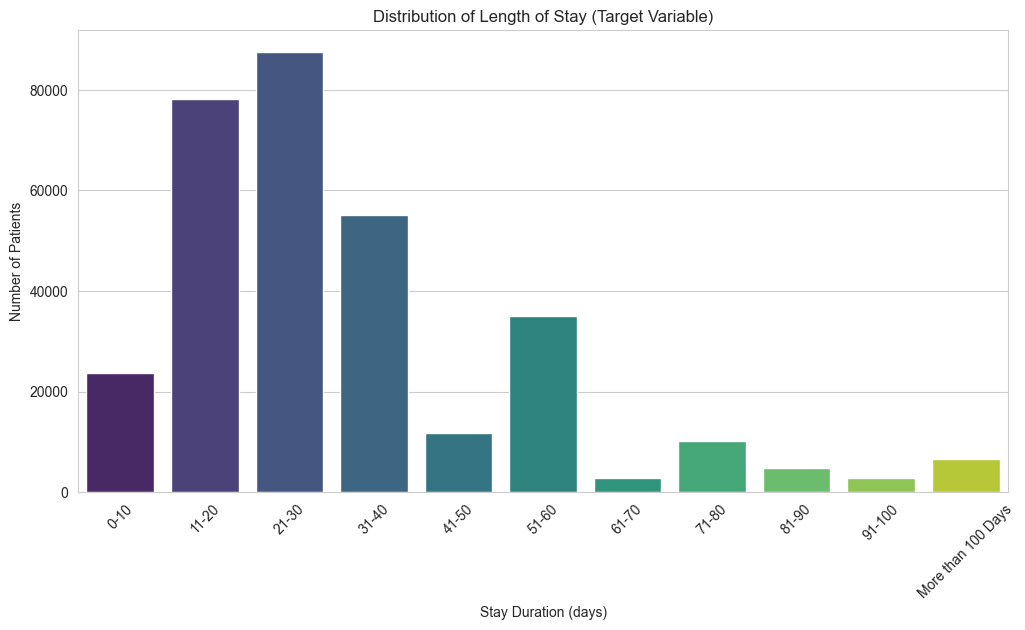

In [18]:
# Chart - 1 visualization code

# Chart 1: Distribution of the target variable - Length of Stay
# A count plot is the natural choice here since Stay is a categorical/ordinal bucket,
# and we want to see how admissions are spread across the different duration ranges
plt.figure(figsize=(12, 6))
sns.countplot(data=df_wrangled, x='Stay', order=stay_order, palette='viridis')
plt.title('Distribution of Length of Stay (Target Variable)')
plt.xlabel('Stay Duration (days)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is the right choice for the target variable since Stay is a categorical/ordinal bucket, not a continuous number. It lets us instantly compare how many patients fall into each duration range and see the overall shape of the distribution.

##### 2. What is/are the insight(s) found from the chart?

The distribution is heavily right-skewed. Most patients (roughly 70%) are discharged within 40 days, with 21-30 days being the single most common stay duration (~87,000 patients). Stays beyond 60 days are rare, but there's a small resurgence at "More than 100 Days" (~6,000 patients) — more than the 61-70, 81-90, and 91-100 buckets combined in some cases, suggesting a distinct sub-population of chronic/long-term patients separate from the general trend.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this has direct positive business impact for hospital resource planning. Since ~70% of patients are discharged within 40 days, hospitals can use this baseline to plan bed turnover, staffing schedules, and short-stay ward capacity more efficiently. On the risk side, the small but persistent "More than 100 Days" group represents a negative-growth signal: these long-stay patients consume disproportionate hospital resources (beds, staff time, equipment) relative to their numbers, which can strain capacity and increase costs if not identified and managed proactively (e.g., through early intervention or specialized long-term care pathways). Also, this class imbalance means our ML models will likely need special handling later (e.g., appropriate evaluation metrics) so that rare-but-important long-stay cases aren't ignored.

#### Chart 2 – Age Distribution

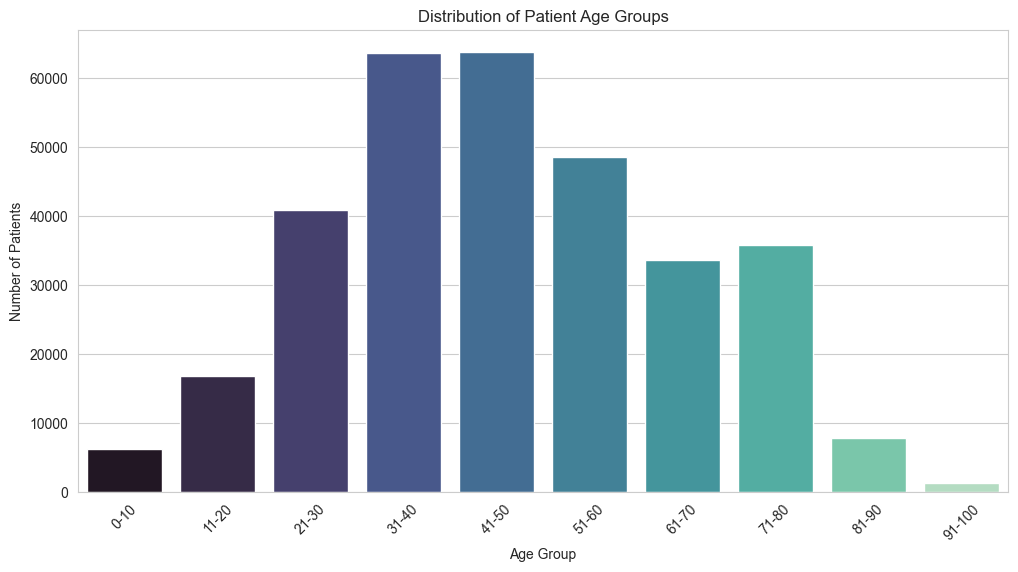

In [19]:
# Chart - 2 visualization code

# Chart 2: Distribution of patient Age groups
# Count plot again since Age is bucketed - helps us see which age groups
# make up most of the hospital's patient base
plt.figure(figsize=(12, 6))
sns.countplot(data=df_wrangled, x='Age', order=age_order, palette='mako')
plt.title('Distribution of Patient Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot suits Age well since it's a bucketed/ordinal categorical variable, and we want to compare patient volume across age groups in order, from youngest to oldest.

##### 2. What is/are the insight(s) found from the chart?

The patient base is concentrated in the middle-aged to older-adult range — 31-40 and 41-50 are the two largest groups (~63,500 patients each), followed by 51-60 (~48,500). Volume tapers off on both ends: very young patients (0-10, 11-20) and the elderly (81-90, 91-100) make up a much smaller share, with 91-100 being the rarest (~1,000 patients). Interestingly, 71-80 has slightly more patients than 61-70, a small but notable break from an otherwise smooth decline.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, positive impact — hospitals can use this age concentration (30–60 age band) to tailor department staffing, equipment allocation, and even preventive health programs toward the working-age population that dominates admissions here. On the risk side, the very small sample sizes in 0-10 and 91-100 age brackets mean any model we train will have limited data to learn patterns for these groups — predictions for very young or very elderly patients may be less reliable, which is a real limitation to flag for a healthcare use case where under-serving edge-case age groups could have real consequences (e.g., an inaccurate stay-length prediction for an elderly patient could affect discharge planning or care allocation).

#### Chart 3 – Admission Deposit Distribution

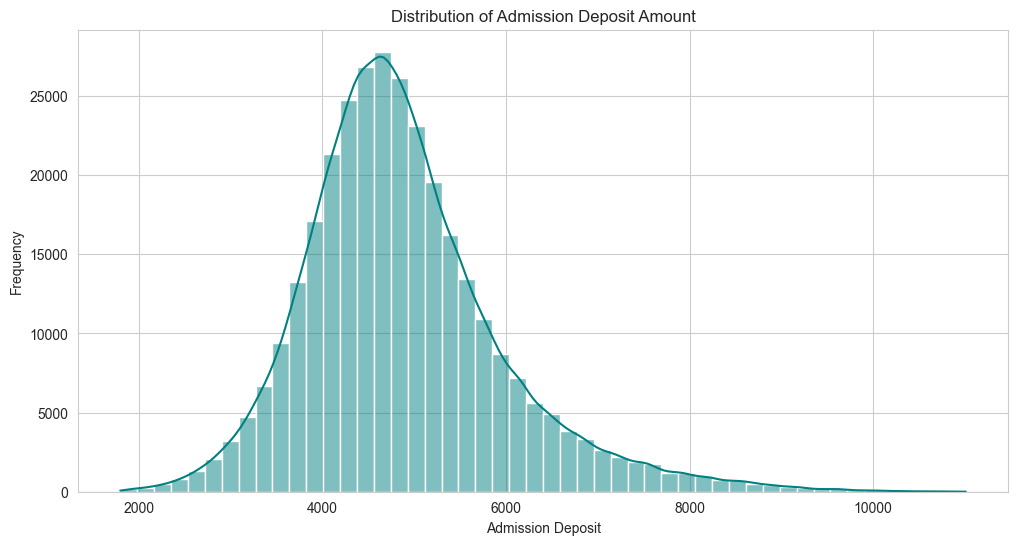

In [20]:
# Chart - 3 visualization code

# Chart 3: Distribution of Admission Deposit
# This is a genuinely continuous numeric column, so a histogram with a KDE curve
# is the right tool - lets us see the shape (skew, spread, any weird spikes)
plt.figure(figsize=(12, 6))
sns.histplot(data=df_wrangled, x='Admission_Deposit', bins=50, kde=True, color='teal')
plt.title('Distribution of Admission Deposit Amount')
plt.xlabel('Admission Deposit')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

Admission_Deposit is a genuinely continuous numeric variable, so a histogram with a KDE overlay is ideal — it shows both the frequency distribution across bins and the smooth underlying shape, letting us spot skewness and outliers at a glance.

##### 2. What is/are the insight(s) found from the chart?

The distribution is unimodal and approximately bell-shaped but with a clear right skew — the peak sits around ₹4,500–5,000, matching what we saw earlier in describe() (mean ≈ 4,880, median ≈ 4,741). Most deposits fall between ₹3,000 and ₹6,500, but there's a long tail stretching out to ₹10,000+, representing a smaller group of high-deposit admissions. This right skew means mean and median are close but not identical, and a few high-value outliers are pulling the tail rightward.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — positive impact for financial planning: hospitals can use this typical deposit range (₹3,000–6,500) as a benchmark for setting admission deposit policies and estimating expected cash flow from new admissions. The long right tail is worth investigating further, though — high-deposit admissions could correlate with higher severity cases or specific departments (something we'll check in the bivariate section). If unexplained, unusually high deposits with no clear justification could indicate inconsistent billing practices across hospitals, which would be a negative-growth/trust risk worth flagging to hospital administration for standardization.

#### Chart 4 – Severity of Illness Distribution

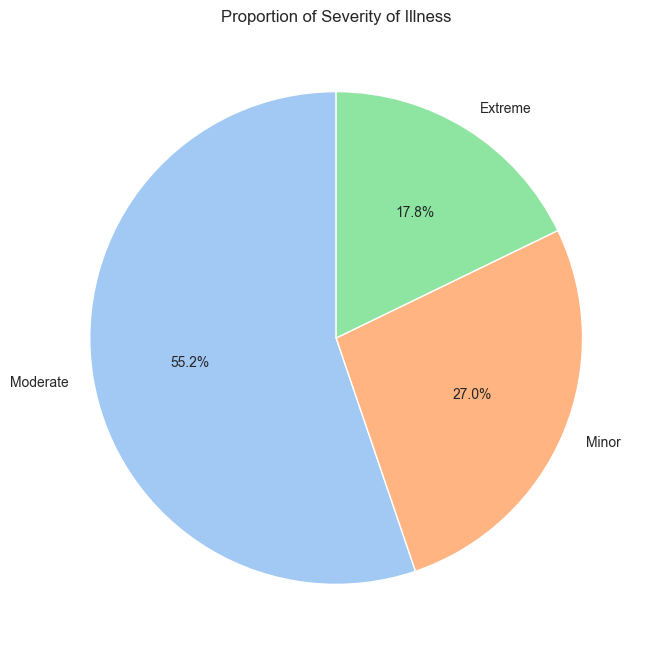

In [21]:
# Chart - 4 visualization code

# Chart 4: Distribution of Severity of Illness
# A pie chart works nicely here since there are only 3 categories and we want
# to quickly show the proportional split at a glance
plt.figure(figsize=(8, 8))
df_wrangled['Severity_of_Illness'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90
)
plt.title('Proportion of Severity of Illness')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is appropriate here since Severity_of_Illness has only 3 categories, and the goal is to show the proportional split of the total patient population at a glance rather than compare exact counts.

##### 2. What is/are the insight(s) found from the chart?

More than half of all admissions (55.2%) are classified as Moderate severity, followed by Minor at 27.0%, and Extreme cases making up the smallest share at 17.8%. This suggests the hospital system handles a mix weighted toward manageable, non-critical cases, with critical (Extreme) cases being a meaningful but minority subset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — positive impact for resource allocation: knowing that ~55% of cases are Moderate severity helps hospitals right-size general ward capacity versus ICU/critical-care capacity, since Extreme cases (17.8%) likely require disproportionately more intensive resources (staff, equipment, monitoring) relative to their share of admissions. On the risk side, if Extreme-severity cases are also correlated with longer stays (which we'll verify in the bivariate section), under-provisioning critical-care capacity based on this ~18% share alone could be risky — severity doesn't scale linearly with resource need, so hospitals shouldn't naively allocate resources proportional to case-count percentages alone.

#### Chart 5 – Severity of Illness vs Stay

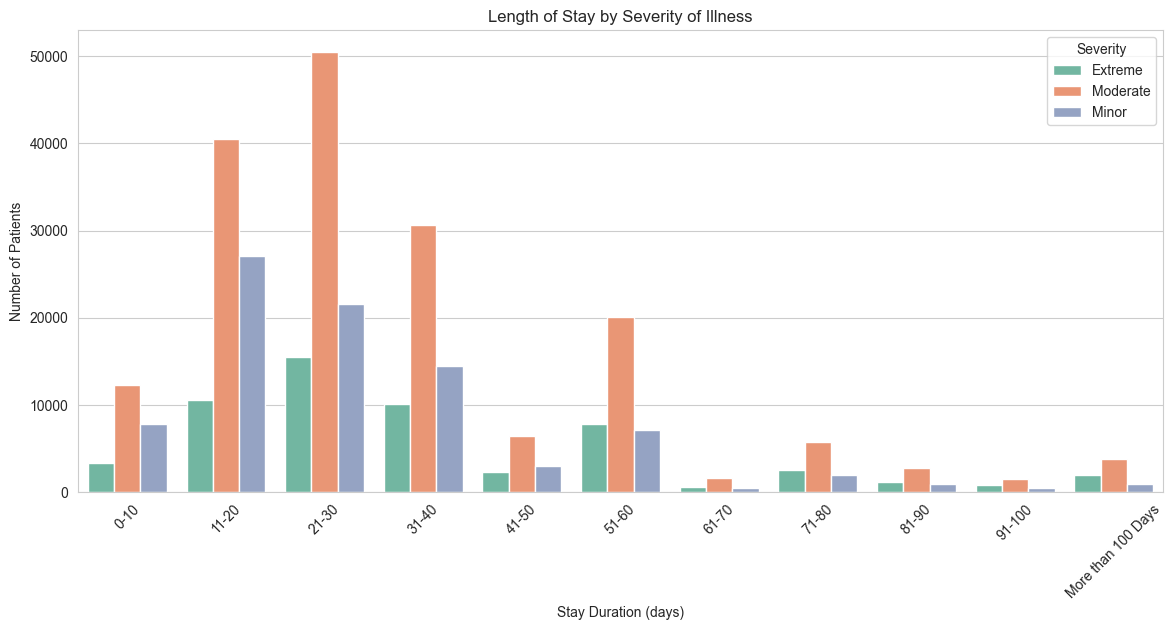

In [22]:
# Chart - 5 visualization code

# Chart 5: How Severity of Illness relates to Length of Stay
# Using a count plot with hue to compare stay-duration distribution across severity levels
plt.figure(figsize=(14, 6))
sns.countplot(data=df_wrangled, x='Stay', hue='Severity_of_Illness', order=stay_order, palette='Set2')
plt.title('Length of Stay by Severity of Illness')
plt.xlabel('Stay Duration (days)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Severity')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped count plot lets us compare the volume of Moderate, Minor, and Extreme cases within each Stay duration bucket side by side, making it easy to see whether severity level shifts the shape of the stay-duration distribution.

##### 2. What is/are the insight(s) found from the chart?

Interestingly, Moderate severity is the tallest bar across almost every single stay bucket, simply because it's the largest overall category (55% of all patients, as seen in Chart 4) — this proportional dominance carries through regardless of stay length. All three severity levels peak at the same bucket (21-30 days) and follow a similar right-skewed shape, which suggests that raw stay duration alone doesn't show an obvious separation by severity in count terms — this is a case where visualizing proportions (percentage within each severity group) would tell a clearer story than raw counts, something worth revisiting with a normalized version of this chart or in the hypothesis testing section.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is actually a caution flag more than a clean win: if hospital planners assumed "Extreme severity = automatically longer stays," this raw chart alone doesn't strongly confirm that visually, since Moderate dominates every bucket by volume. Relying on this chart without normalizing by group size could lead to misleading conclusions and poor resource allocation decisions. The right move is to statistically test whether severity truly influences stay duration (which we'll do formally in the Hypothesis Testing section) rather than relying on visual count comparisons alone — this is a good example of why business decisions shouldn't be based on a single unnormalized chart.

#### Chart 6 – Admission Deposit vs Stay (Numerical-Categorical)

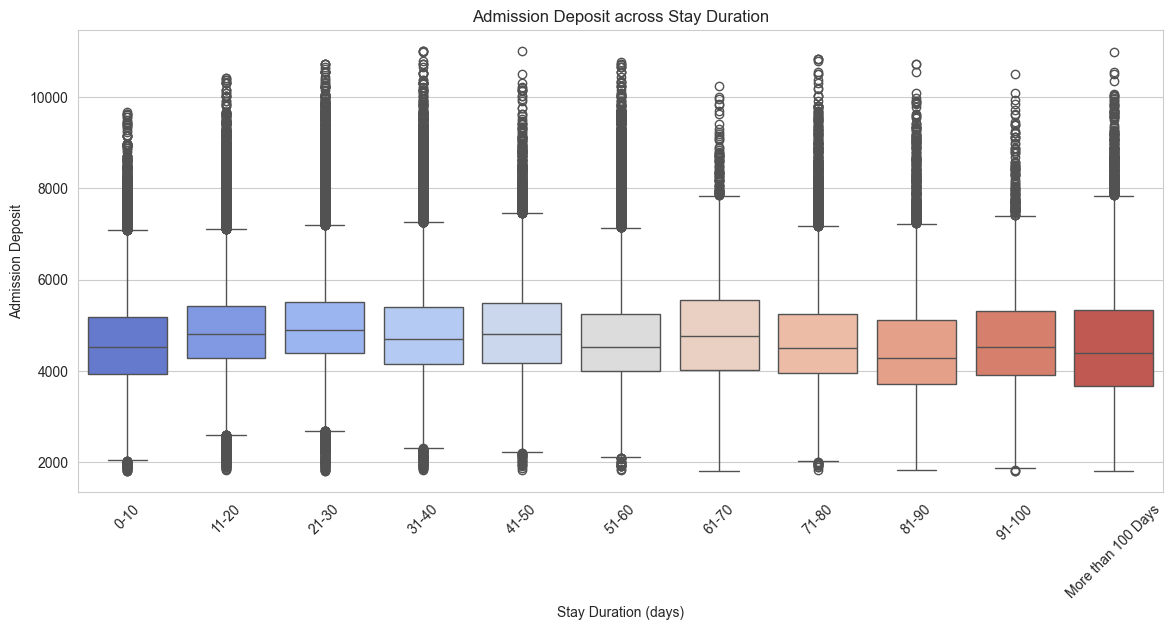

In [23]:
# Chart - 6 visualization code

# Chart 6: How Admission Deposit varies across different Stay durations
# A box plot is ideal here - shows median, spread, and outliers for a numeric
# variable across each category of the ordinal target
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_wrangled, x='Stay', y='Admission_Deposit', order=stay_order, palette='coolwarm')
plt.title('Admission Deposit across Stay Duration')
plt.xlabel('Stay Duration (days)')
plt.ylabel('Admission Deposit')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is the standard tool for comparing a continuous numeric variable (Admission_Deposit) across multiple categories (Stay buckets) — it shows median, interquartile spread, and outliers in one compact view, which is far more informative than just comparing means.

##### 2. What is/are the insight(s) found from the chart?

Surprisingly, the median admission deposit is remarkably stable across all stay-duration buckets, hovering consistently between ₹4,300 and ₹4,900 regardless of whether the stay is 0-10 days or More than 100 Days. The interquartile ranges also look similar in width across buckets. Every single bucket shows a large number of high-value outliers stretching up to ₹10,000+, and this outlier pattern doesn't intensify or shrink meaningfully as stay length increases. This is a fairly flat relationship — Admission_Deposit does not appear to scale with length of stay, which is somewhat counter-intuitive (one might expect deposits to be set higher in anticipation of longer stays).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a useful negative finding: it suggests Admission_Deposit is likely set at time of admission based on factors other than expected stay duration (e.g., department, hospital policy, or a flat/near-flat institutional rate) — meaning hospitals may be under-collecting deposits for patients who end up staying much longer, and over-collecting relative to need for very short stays. From a business standpoint, this is actionable: hospitals could explore a more dynamic deposit-setting policy tied to predicted stay length (which is exactly what this ML project could support) to improve cash flow matching. From a modeling standpoint, it also tells us Admission_Deposit alone may be a weak predictor of Stay — we'll need to rely more on categorical features like Severity, Department, and Admission Type for prediction power, which we should verify through correlation/feature importance later.

#### Chart 7 – Age vs Stay (Numerical-Numerical, using ordinal encodings)

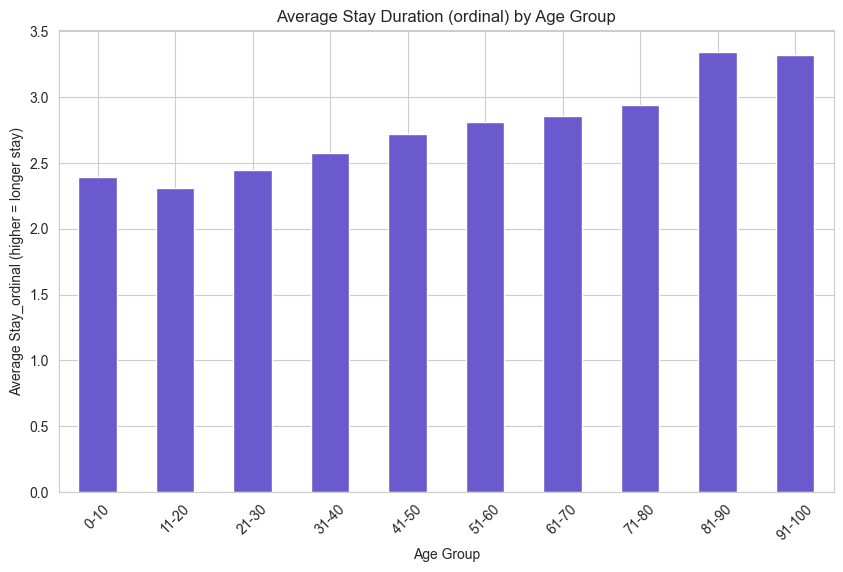

In [24]:
# Chart - 7 visualization code

# Chart 7: Relationship between Age and Stay duration (using their ordinal encodings)
# A scatter-style visualization would be too dense with 300K+ points, so we use
# a heatmap of average Stay_ordinal per Age group - clearer for bucketed ordinal data
age_stay_pivot = df_wrangled.groupby('Age')['Stay_ordinal'].mean().reindex(age_order)
plt.figure(figsize=(10, 6))
age_stay_pivot.plot(kind='bar', color='slateblue')
plt.title('Average Stay Duration (ordinal) by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Stay_ordinal (higher = longer stay)')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Since both Age and Stay are ordinal (ordered) buckets rather than truly continuous numbers, and the dataset has 300K+ rows (too dense for a meaningful scatter plot), a bar chart of the average Stay_ordinal per age group is a cleaner way to visualize the trend between the two ordered variables while keeping the natural age progression on the x-axis.

##### 2. What is/are the insight(s) found from the chart?

There's a clear, mostly monotonic upward trend — average stay duration increases steadily as age increases, starting around 2.3–2.4 (in ordinal terms) for younger patients (0-10 to 21-30) and climbing to roughly 3.3 for the oldest groups (81-90, 91-100). This is one of the strongest and most intuitive relationships we've seen so far: older patients tend to stay in the hospital longer, which aligns with real-world medical expectations (older patients often have more complex or slower-recovering conditions).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, strong positive business impact — this is a genuinely actionable and intuitive insight. Hospitals can use age as an early planning signal at admission time: elderly patients (especially 70+) are statistically likely to require longer bed occupancy, so proactively flagging these cases could improve discharge planning, bed availability forecasting, and staffing for geriatric care. From a modeling perspective, this also confirms Age is likely to be one of our stronger predictive features for the ML models later, unlike Admission_Deposit which showed almost no relationship with Stay in Chart 6. No clear negative-growth signal here — this is a reliable, expected pattern rather than an anomaly.

#### Chart 8 – Department vs Type of Admission (Categorical-Categorical)

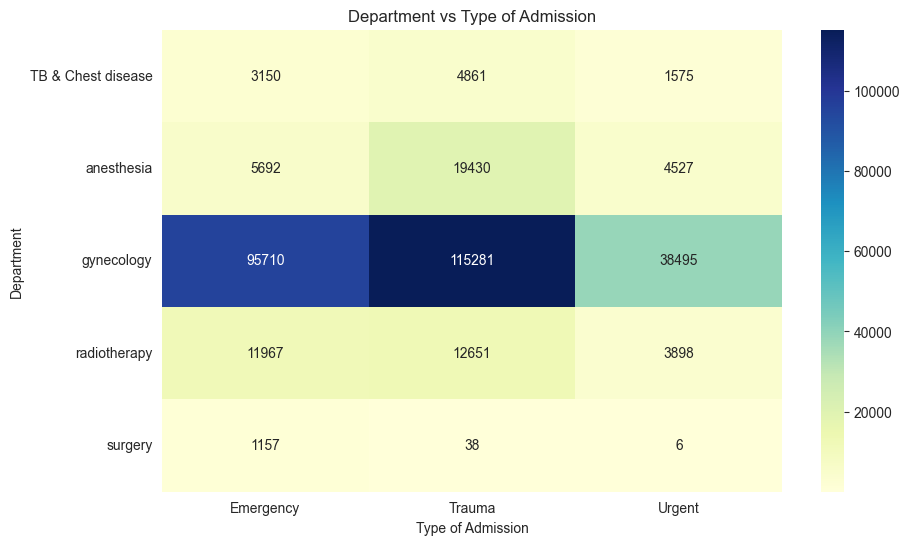

In [25]:
# Chart - 8 visualization code

# Chart 8: Relationship between Department and Type of Admission
# A crosstab heatmap is a clean way to visualize how two categorical variables
# co-occur across all their combinations
crosstab = pd.crosstab(df_wrangled['Department'], df_wrangled['Type_of_Admission'])
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Department vs Type of Admission')
plt.xlabel('Type of Admission')
plt.ylabel('Department')
plt.show()

##### 1. Why did you pick the specific chart?

A crosstab heatmap is ideal for visualizing the relationship between two categorical variables (Department and Type_of_Admission) — the color intensity combined with annotated counts lets us instantly spot which combinations dominate the data and which are rare.

##### 2. What is/are the insight(s) found from the chart?

Gynecology overwhelmingly dominates the entire dataset, accounting for the vast majority of admissions across all three admission types (95,710 Emergency + 115,281 Trauma + 38,495 Urgent = ~249,000 of the 318,438 total records, roughly 78%). Within gynecology, Trauma is the most common admission type. In sharp contrast, the surgery department has almost no records (1,157 Emergency, 38 Trauma, just 6 Urgent) — a total of ~1,200 cases, making it a heavily underrepresented category. Anesthesia, radiotherapy, and TB & Chest disease sit in between, each in the low thousands to tens of thousands range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is an important finding for both business and modeling purposes. On the business side, it confirms gynecology is the primary driver of hospital admission volume in this dataset, so operational focus (staffing, bed allocation, admission process optimization) targeting gynecology + trauma admissions would have the largest overall impact. On the risk side, the extreme sparsity of the surgery department (~0.4% of total records) is a real concern — any model we train will have very little data to learn meaningful patterns for surgery patients, meaning predictions for that department are likely to be unreliable. This is worth flagging explicitly in the Challenges Report: department-level class imbalance may require either excluding ultra-rare categories from certain analyses, grouping them with similar departments, or treating model predictions for surgery with reduced confidence.

#### Chart 9 – Severity of Illness vs Stay, normalized by percentage (fixes the Chart 5 caution flag):

<Figure size 1400x600 with 0 Axes>

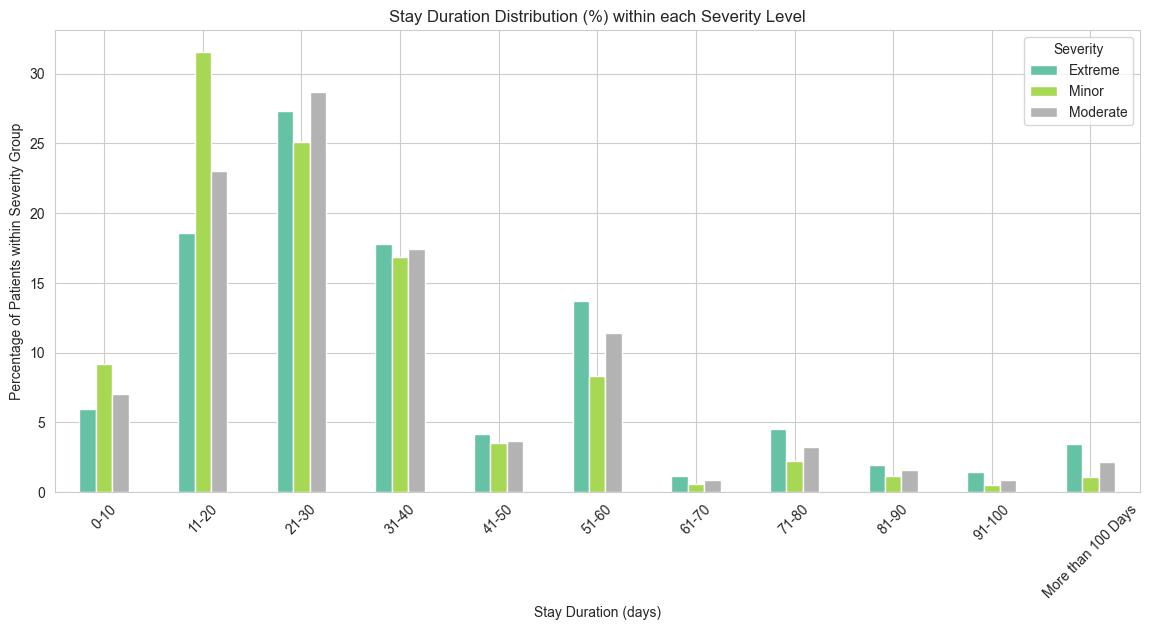

In [26]:
# Chart - 9 visualization code

# Chart 9: Stay distribution by Severity, shown as PERCENTAGE within each severity group
# This fixes the limitation from Chart 5, where raw counts were dominated by
# group size rather than showing the true shape of each severity's stay pattern
severity_stay_pct = pd.crosstab(df_wrangled['Severity_of_Illness'], df_wrangled['Stay'], normalize='index') * 100
severity_stay_pct = severity_stay_pct[stay_order]  # reordering columns to match natural stay order

plt.figure(figsize=(14, 6))
severity_stay_pct.T.plot(kind='bar', figsize=(14, 6), colormap='Set2')
plt.title('Stay Duration Distribution (%) within each Severity Level')
plt.xlabel('Stay Duration (days)')
plt.ylabel('Percentage of Patients within Severity Group')
plt.xticks(rotation=45)
plt.legend(title='Severity')
plt.show()

##### 1. Why did you pick the specific chart?

This chart directly addresses the limitation identified in Chart 5. By normalizing counts to percentages within each severity group (rather than raw counts), we remove the distortion caused by Moderate being the largest group overall, and can now fairly compare the shape of stay-duration distribution across Extreme, Minor, and Moderate severity.

##### 2. What is/are the insight(s) found from the chart?

Now a real pattern emerges: Minor severity patients are more concentrated in short stays — 31.5% fall in the 11-20 day bucket alone, and they drop off sharply after 31-40 days. Extreme severity patients show a noticeably flatter, longer tail — they have higher percentages than Minor in almost every bucket beyond 41-50 days (e.g., 51-60: 13.6% Extreme vs 8.3% Minor; 71-80: 4.5% Extreme vs 2.2% Minor; More than 100 Days: 3.3% Extreme vs just 1.0% Minor). Moderate sits close to Minor in the early buckets but tracks closer to Extreme in the tail. So severity does meaningfully influence stay length — it just wasn't visible in the raw-count chart because of group-size imbalance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strong positive business impact — this confirms Severity_of_Illness is a genuinely useful predictive feature and validates a real clinical intuition: more severe cases disproportionately drive long-stay outcomes. Hospitals can use this to proactively flag Extreme-severity admissions for long-stay-risk management (early discharge planning, resource pre-allocation) rather than treating all admissions the same. This chart also demonstrates a valuable methodological lesson worth including in the Challenges Report: always normalize before comparing distributions across imbalanced groups — Chart 5's raw-count version could have led to a false conclusion that severity doesn't matter, when in fact it does.

#### Chart 10 – Average Stay by Department and Severity (Multivariate)

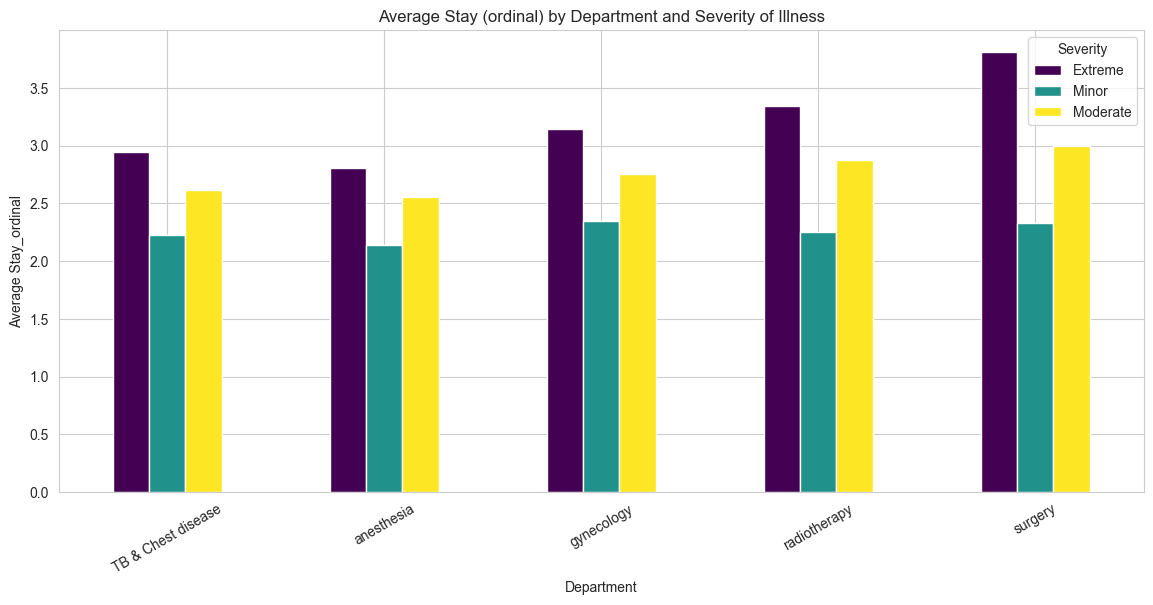

In [27]:
# Chart - 10 visualization code

# Chart 10: Average stay duration broken down by Department AND Severity together
# A grouped bar chart lets us see if certain departments show longer stays
# specifically for Extreme severity cases vs Moderate/Minor
dept_severity_stay = df_wrangled.groupby(['Department', 'Severity_of_Illness'])['Stay_ordinal'].mean().unstack()
dept_severity_stay.plot(kind='bar', figsize=(14, 6), colormap='viridis')
plt.title('Average Stay (ordinal) by Department and Severity of Illness')
plt.xlabel('Department')
plt.ylabel('Average Stay_ordinal')
plt.xticks(rotation=30)
plt.legend(title='Severity')
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart lets us examine Stay_ordinal across two categorical dimensions simultaneously — Department and Severity_of_Illness — so we can check whether the severity effect on stay length (confirmed in Chart 9) holds consistently across all departments, or if certain departments amplify it more than others.

##### 2. What is/are the insight(s) found from the chart?

The pattern is remarkably consistent across all five departments: Extreme severity always produces the longest average stay, Moderate sits in the middle, and Minor is always the shortest — no department reverses this order. That said, the magnitude differs: surgery shows the widest gap between Extreme (~3.8) and Minor (~2.3) severity, and also has the highest Extreme-severity average stay of any department overall. Anesthesia shows the smallest gap and lowest averages across all three severities, suggesting relatively shorter and more consistent stays regardless of severity. Gynecology and radiotherapy sit in between, both trending closer to surgery's pattern than anesthesia's.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact — this strengthens the case that both Department and Severity_of_Illness are reliable, complementary predictors of stay length, and their interaction matters too (department moderates how strongly severity affects stay). This is directly actionable: hospitals can prioritize long-stay-risk protocols specifically for Extreme-severity surgery patients, since that combination produces the longest average stays observed in the entire analysis. One caution flag, tying back to Chart 8: the surgery department has very few total records (~1,200), so while the pattern is directionally consistent with other departments, this specific average should be treated with lower statistical confidence due to the small sample size — a good limitation to note in the Challenges Report.

#### Chart 11 – Available Extra Rooms vs Stay, colored by Hospital Region

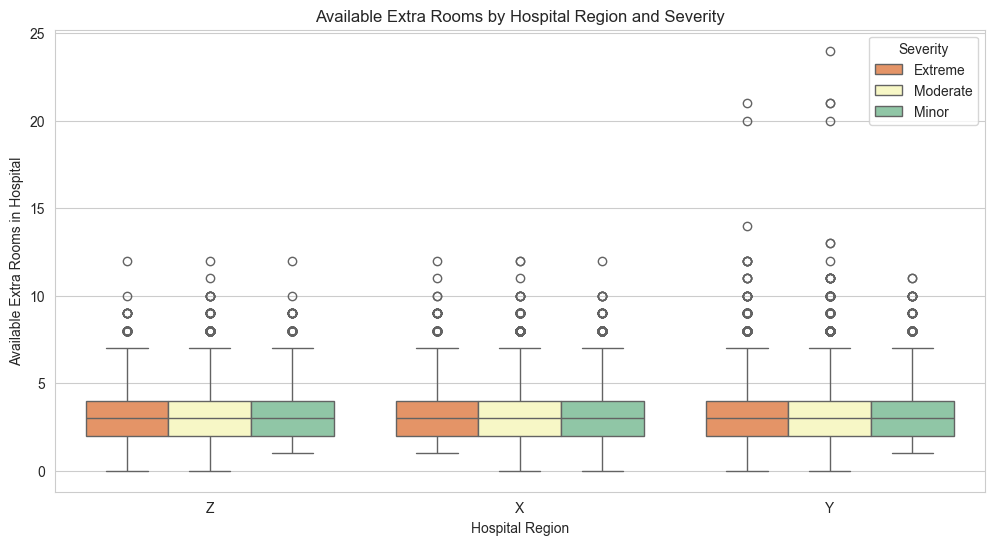

In [28]:
# Chart - 11 visualization code

# Chart 11: Checking if hospital capacity (extra rooms) relates to stay duration,
# and whether this differs by hospital region
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_wrangled, x='Hospital_region_code', y='Available_Extra_Rooms_in_Hospital', 
            hue='Severity_of_Illness', palette='Spectral')
plt.title('Available Extra Rooms by Hospital Region and Severity')
plt.xlabel('Hospital Region')
plt.ylabel('Available Extra Rooms in Hospital')
plt.legend(title='Severity')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot with hue lets us compare the distribution of Available_Extra_Rooms_in_Hospital across both Hospital_region_code and Severity_of_Illness at once — useful for checking whether hospital capacity is allocated differently based on region or case severity.

##### 2. What is/are the insight(s) found from the chart?

The core distributions are nearly identical across all three regions (X, Y, Z) and all three severity levels — median available extra rooms sits consistently around 3, with the interquartile range roughly 2–4 in every single group. This tells us hospital room availability doesn't systematically vary by region or by the severity of the patient being admitted, which is somewhat expected since room availability is a hospital-level operational metric rather than something that would logically respond to individual patient severity. The one notable difference is in the outliers: Region Y shows several extreme outlier values (up to 24 extra rooms), which don't appear in Regions X or Z, suggesting Region Y may include a few larger or less-occupied hospitals in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is primarily a "ruling out" insight rather than a strong positive finding — it tells us Available_Extra_Rooms_in_Hospital likely won't be a strong standalone predictor of Stay, since it doesn't vary meaningfully with severity (which we've already shown is stay-related). That's still valuable for modeling — it helps set expectations and guides feature selection later. On the operational side, the outlier hospitals in Region Y with unusually high room availability could be worth investigating separately — if genuine, they may represent underutilized capacity that could be redirected to relieve pressure on more constrained hospitals in other regions; if data-entry anomalies, they'd need cleaning before being trusted in any capacity-planning decision.

#### Chart 12 – Visitors with Patient vs Stay, split by Age

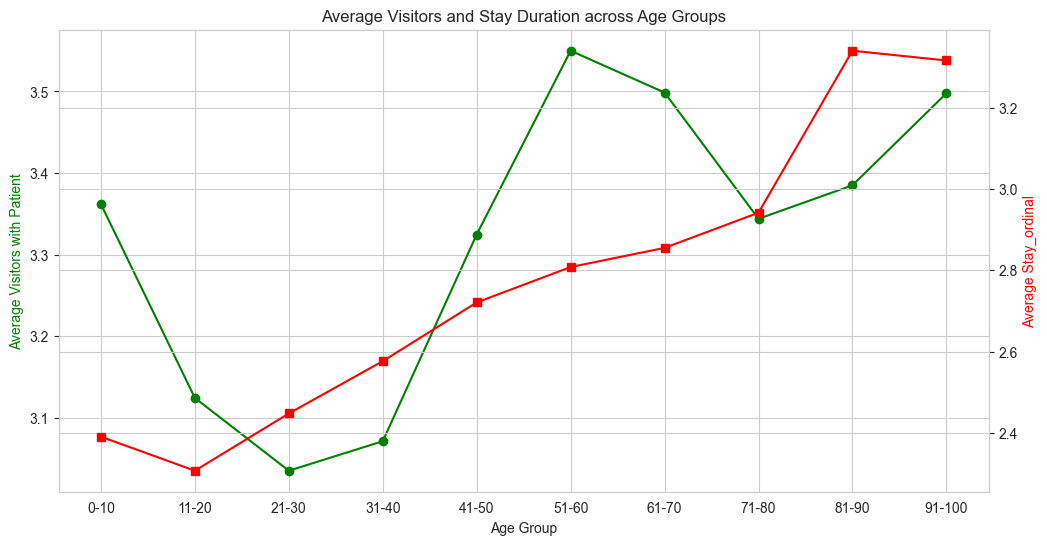

In [29]:
# Chart - 12 visualization code

# Chart 12: Does number of visitors relate to stay duration, and does this pattern
# differ across age groups? Using a line plot to track the trend clearly
visitor_age_stay = df_wrangled.groupby(['Age'])[['Visitors_with_Patient', 'Stay_ordinal']].mean().reindex(age_order)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(visitor_age_stay.index, visitor_age_stay['Visitors_with_Patient'], color='green', marker='o', label='Avg Visitors')
ax2.plot(visitor_age_stay.index, visitor_age_stay['Stay_ordinal'], color='red', marker='s', label='Avg Stay (ordinal)')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Visitors with Patient', color='green')
ax2.set_ylabel('Average Stay_ordinal', color='red')
plt.title('Average Visitors and Stay Duration across Age Groups')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A dual-axis line plot lets us track two different metrics — Visitors_with_Patient and Stay_ordinal — across the same ordered Age axis, making it easy to see whether they rise and fall together or diverge at certain life stages.

##### 2. What is/are the insight(s) found from the chart?

The two lines don't move in perfect lockstep, which is an interesting finding. Average Stay_ordinal (red) shows a fairly steady, near-monotonic increase from age 0-10 through 91-100, echoing what we saw in Chart 7. Average Visitors (green) is more erratic — it starts relatively high for young children (0-10, likely accompanied by parents), dips to its lowest point for young adults (21-30, 31-40), then climbs steadily, peaking around 51-60 before dipping slightly and rising again toward 91-100. The two lines actually cross paths around 21-30 and diverge notably in the 41-50 to 71-80 range, where visitor counts rise faster than stay duration — suggesting visitor support and stay length aren't tightly coupled, especially in middle age.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact — the dip in visitors for young adults (21-30, 31-40) is a useful operational insight: this age group may have fewer available caregivers (often due to work/family constraints of visitors themselves), meaning hospitals could proactively offer additional support services or check-ins for young-adult patients who have less in-person visitor support, particularly if longer stays are involved. On the modeling side, since the two lines don't move together consistently, Visitors_with_Patient likely provides independent, non-redundant information relative to Age — a good sign that including both as separate features should add predictive value rather than one making the other redundant.

#### Chart 13 – Bed Grade vs Stay vs Hospital Type:

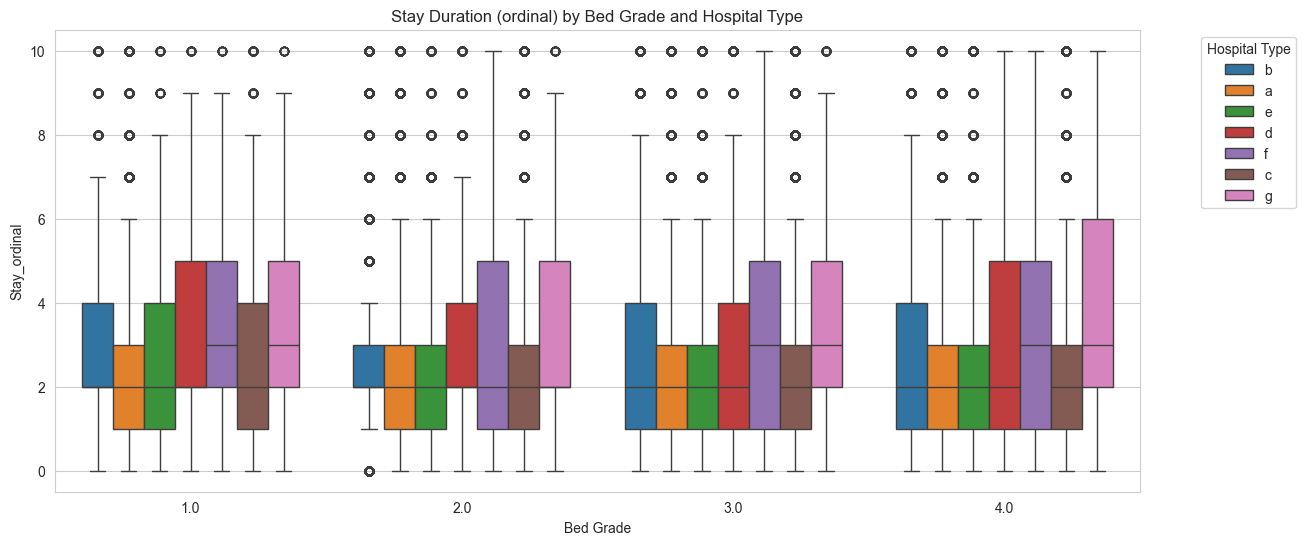

In [30]:
# Chart - 13 visualization code

# Chart 13: Does Bed Grade quality relate to stay duration, and does this vary by Hospital Type?
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_wrangled, x='Bed_Grade', y='Stay_ordinal', hue='Hospital_type_code', palette='tab10')
plt.title('Stay Duration (ordinal) by Bed Grade and Hospital Type')
plt.xlabel('Bed Grade')
plt.ylabel('Stay_ordinal')
plt.legend(title='Hospital Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot with Bed_Grade on the x-axis and Hospital_type_code as the hue lets us check two things simultaneously: whether bed quality grade influences stay duration, and whether that relationship changes depending on which type of hospital the patient is in.

##### 2. What is/are the insight(s) found from the chart?

Bed_Grade itself shows very little consistent effect on Stay_ordinal — medians stay roughly in the 2–3 range across all four bed grades (1.0 through 4.0), with no clear upward or downward trend as bed grade improves. What stands out more is variation across hospital types: hospital types d, f, and g consistently show slightly higher medians (around 3) and wider spread compared to types a, e, and c (median closer to 2), and this pattern holds fairly consistently across all bed grades. So hospital type appears to be a more consistent differentiator of stay length than bed grade is.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mixed but useful insight — the weak relationship between Bed_Grade and Stay suggests bed quality alone isn't a strong lever for predicting or managing stay duration, which is somewhat reassuring (it implies stay length is driven more by patient condition than by room amenities). However, the consistent gap between hospital types (d, f, g vs a, e, c) is worth flagging for operational review — if certain hospital types are systematically associated with longer stays even after accounting for bed grade, it could point to differences in hospital efficiency, protocols, or patient case-mix that administrators should investigate further. This is a case where the insight is a starting point for a deeper investigation rather than an immediately actionable fix.

#### Chart - 14 - Correlation Heatmap

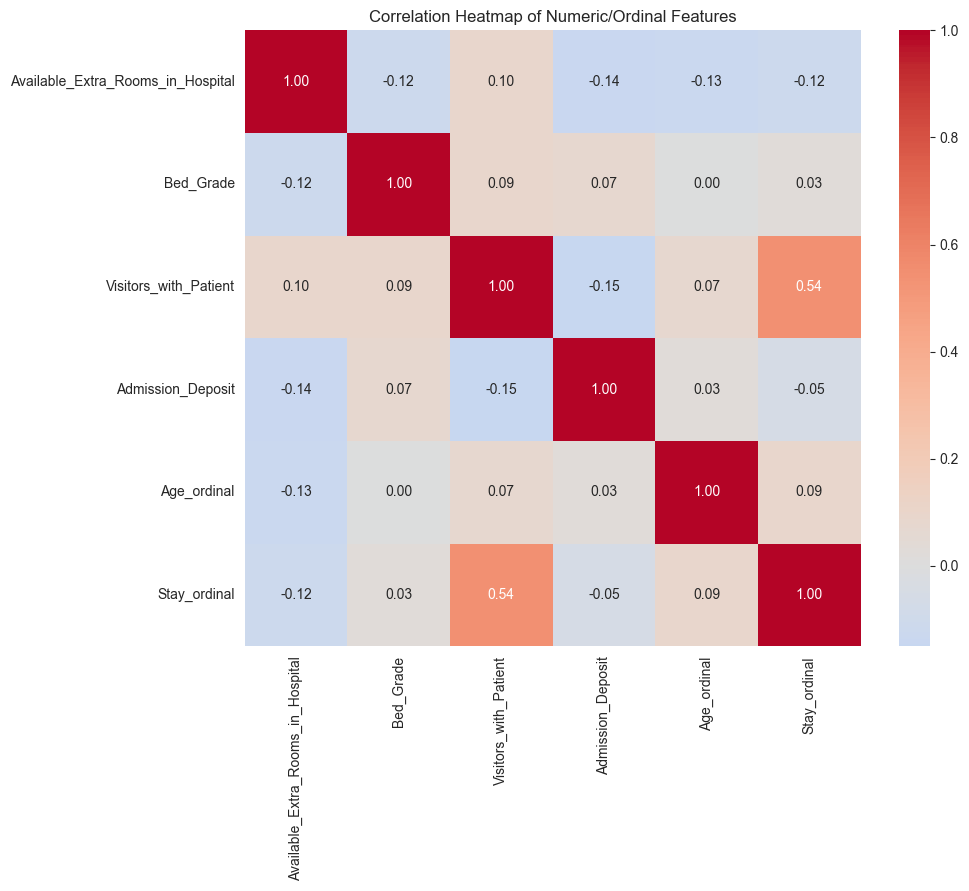

In [31]:
# Correlation Heatmap visualization code

# Chart 14: Correlation Heatmap
# Selecting only the numeric/ordinal columns that make sense to correlate
# (excluding raw category codes that aren't truly ordinal in a linear sense)
numeric_cols = ['Available_Extra_Rooms_in_Hospital', 'Bed_Grade', 'Visitors_with_Patient',
                 'Admission_Deposit', 'Age_ordinal', 'Stay_ordinal']

plt.figure(figsize=(10, 8))
correlation_matrix = df_wrangled[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Numeric/Ordinal Features')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard tool for quickly scanning linear relationships between all numeric/ordinal variable pairs at once, letting us spot which features are strongly related to our target (Stay_ordinal) and which are redundant with each other, without having to build individual scatter plots for every combination.

##### 2. What is/are the insight(s) found from the chart?

The standout finding is that Visitors_with_Patient has by far the strongest correlation with Stay_ordinal (0.54) — notably stronger than Age_ordinal (0.09), which was surprising given how clear the age trend looked visually in Chart 7 (that relationship exists but is weaker in strict linear-correlation terms than it appeared). Every other correlation in the matrix is quite weak — mostly in the -0.15 to 0.10 range — including Admission_Deposit vs Stay_ordinal (-0.05, confirming the flat relationship we saw in Chart 6) and Bed_Grade vs Stay_ordinal (0.03, confirming Chart 13's finding). Importantly, none of the features are highly correlated with each other either (all off-diagonal values are well below 0.6), meaning we don't have a multicollinearity problem to worry about heading into modeling.

#### Chart - 15 - Pair Plot

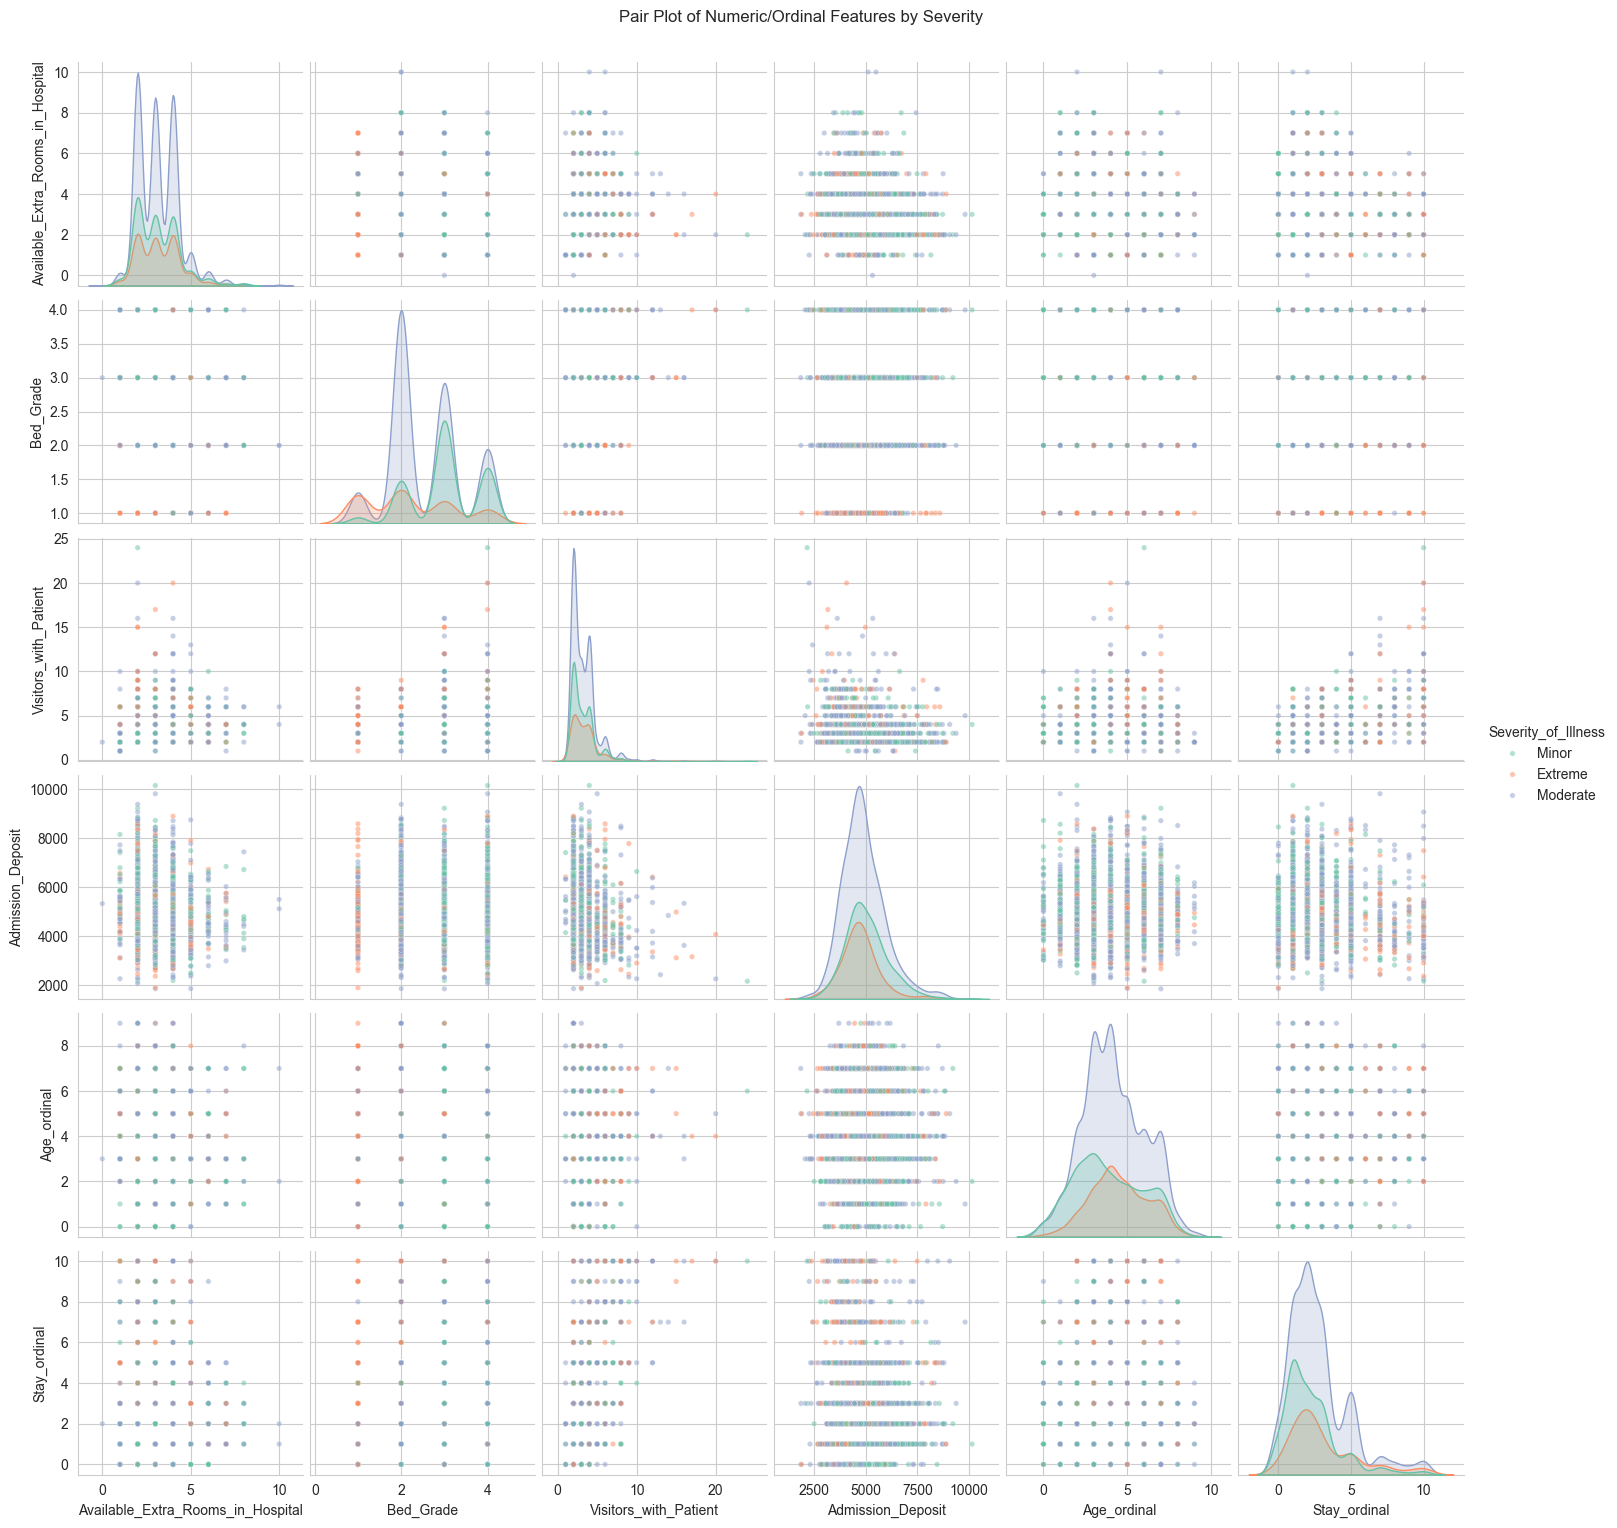

In [32]:
# Pair Plot visualization code

# Chart 15: Pair Plot
# Using the same numeric/ordinal columns, colored by Severity to see if
# separations emerge across multiple feature pairs at once
# Note: sampling the data since a pair plot on 300K+ rows would be extremely slow
sample_df = df_wrangled.sample(n=3000, random_state=42)

sns.pairplot(sample_df[numeric_cols + ['Severity_of_Illness']], hue='Severity_of_Illness',
             palette='Set2', diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15})
plt.suptitle('Pair Plot of Numeric/Ordinal Features by Severity', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot gives a comprehensive multi-panel view of every pairwise relationship between our numeric/ordinal features in one visualization, with severity-level coloring layered on top — useful for spotting non-linear patterns, clustering, or separations that a correlation heatmap (which only captures linear relationships) might miss.

##### 2. What is/are the insight(s) found from the chart?

Most scatter panels show heavily discretized, grid-like patterns rather than smooth continuous spread — this is expected since most of these features (Bed_Grade, Age_ordinal, Stay_ordinal, Available_Extra_Rooms) are ordinal/bucketed rather than truly continuous, so points naturally stack into vertical/horizontal lines. Looking at the diagonal KDE plots by severity, the color separation is fairly subtle across most features — no severity level forms a clearly distinct cluster — except in the Stay_ordinal diagonal panel, where "Moderate" (blue) shows a taller peak at lower Stay_ordinal values while "Extreme" (orange) has relatively more density spread into higher Stay_ordinal values, which reinforces the pattern we already confirmed numerically in Chart 9. No unexpected non-linear relationships or hidden clusters emerged that weren't already visible in the correlation heatmap or earlier bivariate/multivariate charts — this cross-check is reassuring rather than revelatory, confirming our earlier analysis holds up when viewed from multiple angles at once.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the patterns observed during visualization, three hypotheses stood out as worth formal statistical testing: (1) whether Severity of Illness has a real effect on Stay duration — since Chart 5's raw view was misleading until normalized in Chart 9, (2) whether Age genuinely influences Stay duration, given the clear trend in Chart 7 but a surprisingly weak linear correlation in Chart 14, and (3) whether Department affects Stay duration, given the differences seen in Chart 10. Since Stay is ordinal/categorical (not continuous) and we're comparing it across categorical groups, we'll use non-parametric tests appropriate for this data type rather than assuming normality.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant association between Severity of Illness and Length of Stay — the two variables are independent.

Alternate Hypothesis (H1): There is a significant association between Severity of Illness and Length of Stay — the two variables are not independent.

#### 2. Perform an appropriate statistical test.

In [33]:
# Perform Statistical Test to obtain P-Value

# Hypothesis 1: Does Severity of Illness affect Length of Stay?
# H0 (Null): There is no significant association between Severity of Illness and Stay duration.
# H1 (Alternate): There is a significant association between Severity of Illness and Stay duration.

# Using Chi-Square Test of Independence since both variables are categorical
from scipy.stats import chi2_contingency

contingency_table_1 = pd.crosstab(df_wrangled['Severity_of_Illness'], df_wrangled['Stay'])
chi2_stat, p_value_1, dof, expected = chi2_contingency(contingency_table_1)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {p_value_1:.10f}")
print(f"Degrees of Freedom: {dof}")

if p_value_1 < 0.05:
    print("\nResult: Reject the Null Hypothesis - Severity of Illness is significantly associated with Stay duration.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis - No significant association found.")

Chi-Square Statistic: 6616.4816
P-Value: 0.0000000000
Degrees of Freedom: 20

Result: Reject the Null Hypothesis - Severity of Illness is significantly associated with Stay duration.


##### Which statistical test have you done to obtain P-Value?

Chi-Square Test of Independence.

##### Why did you choose the specific statistical test?

Both Severity_of_Illness and Stay are categorical variables (Stay is ordinal, but for this test we treat it as categorical buckets), and the Chi-Square Test of Independence is the standard method for testing whether two categorical variables are associated, by comparing observed frequencies against what we'd expect if they were truly independent. With a p-value of essentially 0 (far below the 0.05 threshold) and a Chi-Square statistic of 6616.48, we reject the null hypothesis — this statistically confirms what Chart 9 showed visually: Severity of Illness and Length of Stay are significantly associated, not independent.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant difference in Length of Stay across different Age groups — the median Stay is the same for all age groups.

Alternate Hypothesis (H1): There is a significant difference in Length of Stay across at least one pair of Age groups — Age influences Stay duration.

#### 2. Perform an appropriate statistical test.

In [34]:
# Perform Statistical Test to obtain P-Value

# Hypothesis 2: Does Age affect Length of Stay?
# H0 (Null): There is no significant difference in Stay duration across Age groups.
# H1 (Alternate): There is a significant difference in Stay duration across Age groups.

# Using Kruskal-Wallis H-test since Stay_ordinal is not normally distributed
# (it's a bucketed ordinal variable, not continuous) and we're comparing more than 2 groups.
# Kruskal-Wallis is the non-parametric alternative to one-way ANOVA.
from scipy.stats import kruskal

age_groups = [df_wrangled[df_wrangled['Age'] == age]['Stay_ordinal'] for age in age_order]
h_stat, p_value_2 = kruskal(*age_groups)

print(f"Kruskal-Wallis H-Statistic: {h_stat:.4f}")
print(f"P-Value: {p_value_2:.10f}")

if p_value_2 < 0.05:
    print("\nResult: Reject the Null Hypothesis - Age significantly affects Stay duration.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis - No significant difference found.")

Kruskal-Wallis H-Statistic: 2880.3154
P-Value: 0.0000000000

Result: Reject the Null Hypothesis - Age significantly affects Stay duration.


##### Which statistical test have you done to obtain P-Value?

Kruskal-Wallis H-test.

##### Why did you choose the specific statistical test?

Stay_ordinal is a bucketed/ordinal variable rather than a normally distributed continuous variable, and we're comparing it across 10 independent Age groups (more than 2 groups), which rules out a standard t-test. The Kruskal-Wallis test is the non-parametric alternative to one-way ANOVA — it doesn't assume normality and works directly on ranks, making it appropriate here. With a p-value of essentially 0 and H-statistic of 2880.32, we reject the null hypothesis, confirming that Age has a statistically significant effect on Stay duration — consistent with the clear upward trend we observed visually in Chart 7, even though the linear correlation coefficient in Chart 14 was relatively low (correlation captures linear strength, while Kruskal-Wallis detects any systematic difference across groups, which is why both results can coexist).

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant difference in Length of Stay across different Departments — the median Stay is the same for all departments.

Alternate Hypothesis (H1): There is a significant difference in Length of Stay across at least one pair of Departments — Department influences Stay duration.

#### 2. Perform an appropriate statistical test.

In [35]:
# Perform Statistical Test to obtain P-Value

# Hypothesis 3: Does Department affect Length of Stay?
# H0 (Null): There is no significant difference in Stay duration across Departments.
# H1 (Alternate): There is a significant difference in Stay duration across Departments.

# Again using Kruskal-Wallis since we're comparing Stay_ordinal (non-normal, ordinal)
# across more than 2 independent groups (5 departments)
dept_groups = [df_wrangled[df_wrangled['Department'] == dept]['Stay_ordinal'] 
               for dept in df_wrangled['Department'].unique()]
h_stat_3, p_value_3 = kruskal(*dept_groups)

print(f"Kruskal-Wallis H-Statistic: {h_stat_3:.4f}")
print(f"P-Value: {p_value_3:.10f}")

if p_value_3 < 0.05:
    print("\nResult: Reject the Null Hypothesis - Department significantly affects Stay duration.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis - No significant difference found.")

Kruskal-Wallis H-Statistic: 361.7925
P-Value: 0.0000000000

Result: Reject the Null Hypothesis - Department significantly affects Stay duration.


##### Which statistical test have you done to obtain P-Value?

Kruskal-Wallis H-test.

##### Why did you choose the specific statistical test?

Same reasoning as Hypothesis 2 — Stay_ordinal is non-normal and ordinal, and we're comparing across 5 independent Department groups, so Kruskal-Wallis is the appropriate non-parametric test. With a p-value of essentially 0 and H-statistic of 361.79, we reject the null hypothesis, confirming Department significantly affects Stay duration. This statistically validates the pattern seen in Chart 10, where departments like surgery consistently showed longer average stays than anesthesia across all severity levels.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [36]:
# Handling Missing Values & Missing Value Imputation

# ------------------------------------------------------------------
# Handling Missing Values & Missing Value Imputation
# (Already performed in the Data Wrangling section - shown here again
# for template completeness, confirming the dataset is fully clean)
# ------------------------------------------------------------------
print("Missing values remaining in the dataset:")
print(df_wrangled.isnull().sum().sum())

Missing values remaining in the dataset:
0


#### What all missing value imputation techniques have you used and why did you use those techniques?

We used mode imputation for both columns with missing values: Bed_Grade (113 missing, ~0.03%) and City_Code_Patient (4,532 missing, ~1.4%). Both are categorical/ordinal codes rather than continuous measurements, so mean or median imputation wouldn't make sense (you can't have a "fractional" bed grade or city code). Mode imputation preserves the most representative category and is a safe choice here given the small proportion of missing data in both columns — it's unlikely to meaningfully distort the distribution or introduce bias into the dataset.

### 2. Handling Outliers

In [37]:
# Handling Outliers & Outlier treatments

# ------------------------------------------------------------------
# Handling Outliers & Outlier Treatment
# Checking outliers using the IQR method for our key continuous numeric columns
# ------------------------------------------------------------------
def get_outlier_bounds(column):
    Q1 = df_wrangled[column].quantile(0.25)
    Q3 = df_wrangled[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

for col in ['Admission_Deposit', 'Visitors_with_Patient']:
    lower, upper = get_outlier_bounds(col)
    outlier_count = df_wrangled[(df_wrangled[col] < lower) | (df_wrangled[col] > upper)].shape[0]
    print(f"{col}: Lower bound = {lower:.2f}, Upper bound = {upper:.2f}, Outliers = {outlier_count} ({outlier_count/len(df_wrangled)*100:.2f}%)")

Admission_Deposit: Lower bound = 2351.50, Upper bound = 7243.50, Outliers = 12316 (3.87%)
Visitors_with_Patient: Lower bound = -1.00, Upper bound = 7.00, Outliers = 9804 (3.08%)


In [38]:
# ------------------------------------------------------------------
# Outlier Treatment: Capping (Winsorization) using IQR bounds
# We cap rather than remove outliers because these are healthcare records -
# an unusually high deposit or visitor count is likely a genuine rare case,
# not a data entry error, so dropping rows would lose real information.
# Capping keeps every record while limiting how much extreme values can
# skew the model.
# ------------------------------------------------------------------
def cap_outliers(df, column):
    lower, upper = get_outlier_bounds(column)
    df[column] = np.where(df[column] < lower, lower, df[column])
    df[column] = np.where(df[column] > upper, upper, df[column])
    return df

for col in ['Admission_Deposit', 'Visitors_with_Patient']:
    df_wrangled = cap_outliers(df_wrangled, col)

# Confirming the capping worked - rechecking outlier counts, should now be 0
for col in ['Admission_Deposit', 'Visitors_with_Patient']:
    lower, upper = get_outlier_bounds(col)
    outlier_count = df_wrangled[(df_wrangled[col] < lower) | (df_wrangled[col] > upper)].shape[0]
    print(f"{col}: Outliers remaining after capping = {outlier_count}")

Admission_Deposit: Outliers remaining after capping = 0
Visitors_with_Patient: Outliers remaining after capping = 0


##### What all outlier treatment techniques have you used and why did you use those techniques?

We used the IQR (Interquartile Range) method to detect outliers in Admission_Deposit (3.87% of records) and Visitors_with_Patient (3.08% of records) — both showed a modest but non-trivial share of extreme values. Rather than removing these rows, we chose capping (Winsorization), which clips values beyond the lower/upper IQR bounds to the bound itself instead of deleting the record. We chose capping over removal for two reasons: (1) this is healthcare data, where an unusually high deposit or visitor count is likely a genuine rare case (e.g., a complex/expensive procedure, or a patient with a large family) rather than a data entry error, so deleting these rows would discard real, valid information and reduce our already-imbalanced long-stay sample even further; (2) capping still limits the disproportionate influence extreme values can have on models sensitive to scale (like linear regression), giving us a good balance between robustness and information retention.

### 3. Categorical Encoding

In [39]:
# Encode your categorical columns

# ------------------------------------------------------------------
# Categorical Encoding
# ------------------------------------------------------------------

# Making a fresh copy to work on for modeling, keeping df_wrangled intact for reference
df_model = df_wrangled.copy()

# 1. Ordinal Encoding for Severity_of_Illness (has a genuine order: Minor < Moderate < Extreme)
severity_order = {'Minor': 0, 'Moderate': 1, 'Extreme': 2}
df_model['Severity_of_Illness'] = df_model['Severity_of_Illness'].map(severity_order)

# Age is already ordinally encoded as Age_ordinal, so we drop the original text column
df_model = df_model.drop(columns=['Age'])

# 2. Label Encoding for high-cardinality ID-like codes
# These are essentially unique identifiers for hospitals/cities, not meaningful
# categories with real-world order, so label encoding keeps things compact
label_enc_cols = ['Hospital_code', 'City_Code_Hospital', 'City_Code_Patient']
label_encoders = {}
for col in label_enc_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le  # saving encoders in case we need to inverse-transform later

# 3. One-Hot Encoding for low-cardinality nominal columns
# These have no inherent order, so one-hot avoids implying a false ranking
onehot_cols = ['Hospital_type_code', 'Hospital_region_code', 'Department', 
               'Ward_Type', 'Ward_Facility_Code', 'Type_of_Admission']
df_model = pd.get_dummies(df_model, columns=onehot_cols, drop_first=True)

# Confirming the shape and checking for any remaining object/text columns
print("Shape after encoding:", df_model.shape)
print("\nRemaining non-numeric columns:", df_model.select_dtypes(include='object').columns.tolist())

Shape after encoding: (318438, 36)

Remaining non-numeric columns: ['Stay']


#### What all categorical encoding techniques have you used & why did you use those techniques?

We used three different encoding strategies depending on the nature of each categorical column:

Ordinal Encoding for Severity_of_Illness (mapped Minor=0, Moderate=1, Extreme=2) since it has a genuine, meaningful order — treating it as ordinal preserves that ranking information for the model, which one-hot encoding would discard. Age was already ordinally encoded earlier (Age_ordinal) for the same reason, so the original text column was dropped to avoid duplication.
Label Encoding for Hospital_code, City_Code_Hospital, and City_Code_Patient — these are essentially ID-like codes (32, 11, and 37 unique values respectively) with no real-world ordinal meaning, but one-hot encoding them would have added dozens of sparse columns and significantly bloated the feature space. Since we're primarily using tree-based models (which don't assume a linear relationship between encoded integers), label encoding is a reasonable, memory-efficient choice here.
One-Hot Encoding for the remaining low-cardinality nominal columns (Hospital_type_code, Hospital_region_code, Department, Ward_Type, Ward_Facility_Code, Type_of_Admission) — these have no inherent order (e.g., "Trauma" isn't greater or less than "Emergency"), so one-hot encoding avoids imposing a false numeric ranking that a model could mistakenly learn as meaningful. We used drop_first=True to avoid the dummy variable trap (multicollinearity from redundant columns).

After encoding, the dataset grew from 16 to 36 columns, with only the original Stay text column remaining non-numeric — which we intentionally kept aside since we already have Stay_ordinal and Stay_days_est as our numeric target options for modeling.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [40]:
# Manipulate Features to minimize feature correlation and create new features

# ------------------------------------------------------------------
# Feature Manipulation: Checking for highly correlated features
# to catch any redundancy introduced during encoding (e.g., one-hot
# columns that might end up near-duplicate of another feature)
# ------------------------------------------------------------------
corr_check = df_model.drop(columns=['Stay']).corr()

high_corr_pairs = []
for i in range(len(corr_check.columns)):
    for j in range(i+1, len(corr_check.columns)):
        if abs(corr_check.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr_check.columns[i], corr_check.columns[j], corr_check.iloc[i, j]))

print("Highly correlated feature pairs (|correlation| > 0.8):")
for pair in high_corr_pairs:
    print(pair)

if not high_corr_pairs:
    print("None found - no strong multicollinearity detected among features.")

Highly correlated feature pairs (|correlation| > 0.8):
('Stay_ordinal', 'Stay_days_est', np.float64(0.999595544859835))
('Hospital_type_code_b', 'Ward_Facility_Code_D', np.float64(0.8385378829473155))
('Hospital_type_code_c', 'Hospital_region_code_Z', np.float64(0.8293226870297215))


In [41]:
# ------------------------------------------------------------------
# Feature Manipulation: Resolving the multicollinearity found above
# ------------------------------------------------------------------

# 1. Stay_ordinal vs Stay_days_est: these are two numeric versions of the SAME target,
#    not independent features, so this correlation is expected and not a concern.
#    We'll keep Stay_ordinal as our primary target for now and drop Stay_days_est
#    from the feature set (we can bring it back later if we want to try true
#    regression instead of ordinal classification).

# 2. Hospital_type_code_b vs Ward_Facility_Code_D (corr = 0.84):
#    This tells us hospital type 'b' almost always uses ward facility 'D' -
#    essentially redundant information. We'll drop one of the two to reduce redundancy.

# 3. Hospital_type_code_c vs Hospital_region_code_Z (corr = 0.83):
#    Similarly, hospital type 'c' is concentrated in region 'Z'. We'll drop one here too.

# Dropping the redundant one-hot columns (keeping the more granular/informative one in each pair)
df_model = df_model.drop(columns=['Ward_Facility_Code_D', 'Hospital_region_code_Z'])

# Confirming the new shape after dropping redundant columns
print("Shape after removing redundant features:", df_model.shape)

Shape after removing redundant features: (318438, 34)


#### 2. Feature Selection

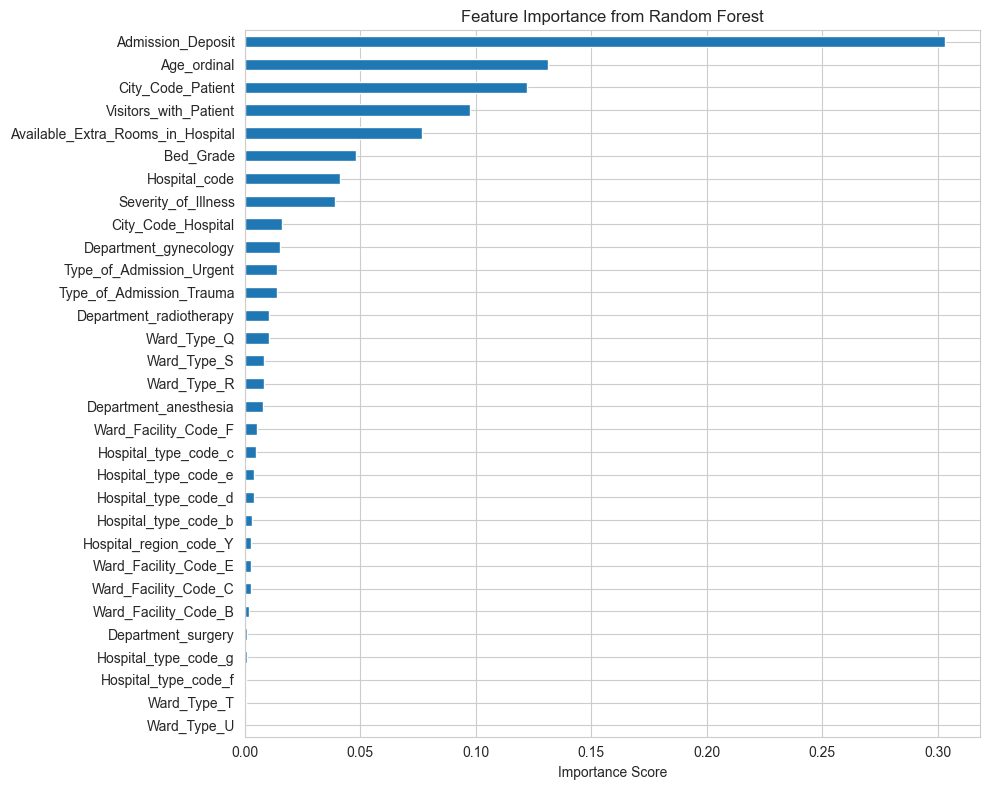

Admission_Deposit                    0.303168
Age_ordinal                          0.131385
City_Code_Patient                    0.122274
Visitors_with_Patient                0.097561
Available_Extra_Rooms_in_Hospital    0.076591
Bed_Grade                            0.048218
Hospital_code                        0.041095
Severity_of_Illness                  0.038938
City_Code_Hospital                   0.016216
Department_gynecology                0.015412
Type_of_Admission_Urgent             0.014201
Type_of_Admission_Trauma             0.013934
Department_radiotherapy              0.010636
Ward_Type_Q                          0.010489
Ward_Type_S                          0.008436
Ward_Type_R                          0.008251
Department_anesthesia                0.008162
Ward_Facility_Code_F                 0.005302
Hospital_type_code_c                 0.005012
Hospital_type_code_e                 0.003983
Hospital_type_code_d                 0.003882
Hospital_type_code_b              

In [42]:
# Select your features wisely to avoid overfitting

# ------------------------------------------------------------------
# Feature Selection: Using Random Forest feature importance
# to identify which features carry the most predictive signal
# for Stay_ordinal, before finalizing our modeling dataset
# ------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

# Preparing X and y - dropping target-related columns from features
X_temp = df_model.drop(columns=['Stay', 'Stay_ordinal', 'Stay_days_est'])
y_temp = df_model['Stay_ordinal']

# Training a quick baseline Random Forest just to extract feature importances
# (not our final model - just a diagnostic tool for feature selection)
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_temp, y_temp)

# Extracting and sorting feature importances
feature_importance = pd.Series(rf_selector.feature_importances_, index=X_temp.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feature_importance.plot(kind='barh')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance)

In [43]:
# ------------------------------------------------------------------
# Feature Selection: Dropping features with negligible importance
# Using a threshold of 0.001 - features below this contribute almost
# nothing to the model's predictive power and only add noise/dimensionality
# ------------------------------------------------------------------
low_importance_features = feature_importance[feature_importance < 0.001].index.tolist()
print("Dropping low-importance features:", low_importance_features)

df_model = df_model.drop(columns=low_importance_features)
print("\nShape after feature selection:", df_model.shape)

Dropping low-importance features: ['Hospital_type_code_f', 'Ward_Type_T', 'Ward_Type_U']

Shape after feature selection: (318438, 31)


##### What all feature selection methods have you used  and why?

We used Random Forest feature importance as our feature selection method — training a quick diagnostic Random Forest on all encoded features and examining the feature_importances_ scores. We chose this over simpler filter methods (like correlation-based selection alone) because Random Forest captures non-linear relationships and feature interactions, which matters here — as we discovered, Admission_Deposit ranked as the most important feature despite showing almost no linear correlation with the target in our earlier correlation heatmap. We then dropped features with importance below a 0.001 threshold, since these contributed negligible predictive signal while adding unnecessary dimensionality.

##### Which all features you found important and why?

The top predictive features were Admission_Deposit (0.30), Age_ordinal (0.13), City_Code_Patient (0.12), Visitors_with_Patient (0.10), and Available_Extra_Rooms_in_Hospital (0.08) — together these five account for roughly 73% of total feature importance. This aligns with our hypothesis testing and visual analysis: Age was statistically confirmed to affect Stay (Hypothesis 2), and Visitors showed the strongest linear correlation with Stay in Chart 14. Admission_Deposit's top ranking, despite weak linear correlation, suggests it interacts with other features (like Department or Severity) in ways that only a non-linear model can capture — worth exploring further with SHAP values once we build our final model. Most of the one-hot encoded categorical dummy columns (representing specific hospital types, ward types, and departments) individually contributed very little, which makes sense since their combined/aggregate effect is what matters, not any single category in isolation.

### 5. Data Transformation

Original skewness of Admission_Deposit: 0.4542
Skewness after log transform: -0.1799


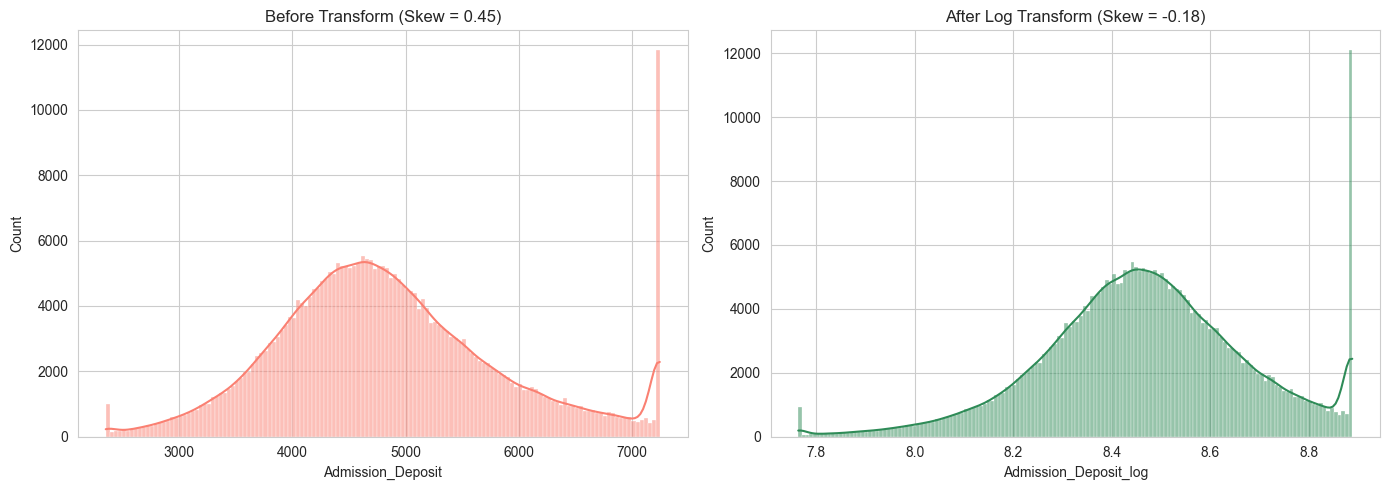

In [44]:
# Transform Your data

# ------------------------------------------------------------------
# Data Transformation: Checking skewness of Admission_Deposit
# and applying a log transform if it's significantly skewed
# ------------------------------------------------------------------
from scipy.stats import skew

original_skew = skew(df_model['Admission_Deposit'])
print(f"Original skewness of Admission_Deposit: {original_skew:.4f}")

# Applying log transformation (log1p handles zero values safely, though we don't have any here)
df_model['Admission_Deposit_log'] = np.log1p(df_model['Admission_Deposit'])
transformed_skew = skew(df_model['Admission_Deposit_log'])
print(f"Skewness after log transform: {transformed_skew:.4f}")

# Visual comparison - before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_model['Admission_Deposit'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title(f'Before Transform (Skew = {original_skew:.2f})')
sns.histplot(df_model['Admission_Deposit_log'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'After Log Transform (Skew = {transformed_skew:.2f})')
plt.tight_layout()
plt.show()

In [45]:
# ------------------------------------------------------------------
# Keeping both original and log-transformed Admission_Deposit for now.
# We'll decide which version to use per-model during ML implementation -
# tree-based models don't need this transform, but it may help linear models.
# ------------------------------------------------------------------
print("Both 'Admission_Deposit' and 'Admission_Deposit_log' are available in df_model.")
print("Current shape:", df_model.shape)

Both 'Admission_Deposit' and 'Admission_Deposit_log' are available in df_model.
Current shape: (318438, 32)


#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Admission_Deposit showed moderate right-skewness (0.45) in our earlier visualization (Chart 3), so we tested a log transformation (log1p) to see if it would normalize the distribution. The transform reduced the skew magnitude from 0.45 to -0.18 — a meaningful improvement, though it slightly overcorrected into mild left-skew territory. We're keeping both the original and log-transformed versions available in the dataset: since our primary planned models are tree-based (Random Forest, Gradient Boosting), which are inherently insensitive to feature scale and skew, this transformation isn't strictly required for those models. However, we retain the log-transformed column in case we also evaluate a linear/distance-based model for comparison, where reduced skew could meaningfully improve performance.

### 6. Data Scaling

In [46]:
# Scaling your data

# ------------------------------------------------------------------
# Data Scaling: Applying StandardScaler to continuous numeric columns
# Tree-based models don't require scaling, but we prepare scaled versions
# in case we compare against scale-sensitive models (e.g. Logistic Regression)
# ------------------------------------------------------------------
continuous_cols = ['Admission_Deposit', 'Visitors_with_Patient', 'Available_Extra_Rooms_in_Hospital']

scaler = StandardScaler()
df_model_scaled = df_model.copy()
df_model_scaled[continuous_cols] = scaler.fit_transform(df_model_scaled[continuous_cols])

# Quick check - scaled columns should now have mean ~0 and std ~1
print(df_model_scaled[continuous_cols].describe().loc[['mean', 'std']])

      Admission_Deposit  Visitors_with_Patient  \
mean      -1.513740e-16          -1.213848e-17   
std        1.000002e+00           1.000002e+00   

      Available_Extra_Rooms_in_Hospital  
mean                       1.542301e-16  
std                        1.000002e+00  


#### Which method have you used to scale you data and why?

We used StandardScaler to scale our three continuous numeric columns (Admission_Deposit, Visitors_with_Patient, Available_Extra_Rooms_in_Hospital), which transforms each to have a mean of 0 and standard deviation of 1. We chose StandardScaler over Min-Max scaling because our data (particularly Admission_Deposit) still has some spread and mild skew even after capping outliers, and StandardScaler is generally more robust to this than Min-Max, which compresses everything into a fixed [0,1] range and is more sensitive to any remaining extreme values. That said, since our primary planned models are tree-based (Random Forest, Gradient Boosting) — which are scale-invariant by nature — this scaled version (df_model_scaled) is prepared mainly for due diligence and for use if we test a scale-sensitive model like Logistic Regression for comparison; our unscaled df_model remains the primary dataset for the tree-based models.

### 7. Dimesionality Reduction

In [47]:
# ------------------------------------------------------------------
# Checking whether Dimensionality Reduction is actually needed
# We already removed multicollinear pairs and low-importance features,
# so let's verify our current feature count and correlation structure
# before deciding.
# ------------------------------------------------------------------
print(f"Current number of features (excluding target columns): {df_model.drop(columns=['Stay', 'Stay_ordinal', 'Stay_days_est']).shape[1]}")

# Re-checking for any remaining strong correlations after our cleanup
corr_final = df_model.drop(columns=['Stay']).corr()
high_corr_remaining = []
for i in range(len(corr_final.columns)):
    for j in range(i+1, len(corr_final.columns)):
        if abs(corr_final.iloc[i, j]) > 0.8 and corr_final.columns[i] not in ['Stay_ordinal', 'Stay_days_est'] and corr_final.columns[j] not in ['Stay_ordinal', 'Stay_days_est']:
            high_corr_remaining.append((corr_final.columns[i], corr_final.columns[j], corr_final.iloc[i, j]))

print(f"Remaining high-correlation pairs (excluding target): {high_corr_remaining}")

Current number of features (excluding target columns): 29
Remaining high-correlation pairs (excluding target): [('Admission_Deposit', 'Admission_Deposit_log', np.float64(0.9890305552559742))]


##### Do you think that dimensionality reduction is needed? Explain Why?

No, we don't believe dimensionality reduction (like PCA) is needed for this dataset. After feature manipulation and selection, we're left with a manageable 29 features (excluding target columns) — this is nowhere close to the "curse of dimensionality" territory where PCA typically becomes valuable (usually hundreds+ of features, or cases with severe multicollinearity). The only remaining high-correlation pair (Admission_Deposit and Admission_Deposit_log, r=0.99) is expected and not a concern, since one is simply a transformed version of the other — we'll only use one version at a time depending on the model, not both together. Additionally, this is a healthcare use case where interpretability matters — hospital administrators need to understand which specific factors (e.g., Age, Severity, Admission Deposit) drive a long-stay prediction in order to act on it, and PCA would collapse these into abstract components that lose that direct interpretability. Given the manageable feature count and the importance of explainability here, we're proceeding without dimensionality reduction.

### 8. Data Splitting

In [48]:
# Split your data to train and test. Choose Splitting ratio wisely.

# ------------------------------------------------------------------
# Data Splitting: 80% Train, 20% Test
# With 318K+ rows, an 80/20 split still leaves ~64K rows for testing -
# more than enough for reliable evaluation, while maximizing the data
# available for the model to learn from.
# We use stratify=y to preserve the same class distribution of Stay_ordinal
# in both train and test sets, since we know from Chart 1 that Stay is
# quite imbalanced (e.g., '21-30' days is far more common than '61-70').
# ------------------------------------------------------------------

# Preparing final X and y - using the unscaled df_model as our primary dataset
# since our main models will be tree-based
X = df_model.drop(columns=['Stay', 'Stay_ordinal', 'Stay_days_est', 'Admission_Deposit_log'])
y = df_model['Stay_ordinal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nClass distribution in y_train:\n{y_train.value_counts(normalize=True).sort_index()}")
print(f"\nClass distribution in y_test:\n{y_test.value_counts(normalize=True).sort_index()}")

Training set shape: (254750, 28)
Test set shape: (63688, 28)

Class distribution in y_train:
Stay_ordinal
0     0.074124
1     0.245382
2     0.274752
3     0.173217
4     0.036875
5     0.109967
6     0.008616
7     0.032200
8     0.015195
9     0.008683
10    0.020989
Name: proportion, dtype: float64

Class distribution in y_test:
Stay_ordinal
0     0.074127
1     0.245384
2     0.274746
3     0.173219
4     0.036883
5     0.109974
6     0.008620
7     0.032204
8     0.015183
9     0.008683
10    0.020977
Name: proportion, dtype: float64


##### What data splitting ratio have you used and why?

We used an 80/20 train-test split. With 318,438 total records, even a 20% test set gives us ~63,700 samples — more than sufficient for a statistically reliable evaluation — while the 80% training portion (~254,750 rows) gives our models ample data to learn the complex patterns across 29 features and 11 target classes. We also used stratified splitting (stratify=y) to ensure the class distribution of Stay_ordinal is preserved identically in both train and test sets, which was essential given the significant class imbalance we've observed throughout (e.g., class 2 / "21-30 days" makes up ~27.5% of records, while class 6 / "61-70 days" is only ~0.86%). Without stratification, a random split could easily under-represent rare classes in either the train or test set, leading to unreliable evaluation metrics.

### 9. Handling Imbalanced Dataset

In [49]:
# ------------------------------------------------------------------
# Checking exact class imbalance in the training set
# ------------------------------------------------------------------
class_counts = y_train.value_counts().sort_index()
print("Class counts in training set:")
print(class_counts)
print(f"\nImbalance ratio (largest class / smallest class): {class_counts.max() / class_counts.min():.2f}")

Class counts in training set:
Stay_ordinal
0     18883
1     62511
2     69993
3     44127
4      9394
5     28014
6      2195
7      8203
8      3871
9      2212
10     5347
Name: count, dtype: int64

Imbalance ratio (largest class / smallest class): 31.89


##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset is significantly imbalanced. The training set shows an imbalance ratio of 31.89:1 between the largest class (class 2, "21-30 days", 69,993 samples) and the smallest class (class 6, "61-70 days", 2,195 samples). This mirrors what we observed visually back in Chart 1 — most patients fall into the shorter/mid-range stay durations, while longer stays (especially the 61-70 and 91-100 day ranges) are rare. Ironically, these rare long-stay classes are also the ones most valuable to correctly identify from a hospital resource-planning perspective, making this imbalance a real modeling challenge, not just a statistical curiosity.

In [50]:
# ------------------------------------------------------------------
# Handling Imbalanced Dataset
# We will NOT use resampling techniques like SMOTE here, since we have
# 11 ordinal classes with a 32:1 imbalance ratio - generating synthetic
# samples across that many overlapping ordinal categories risks creating
# unrealistic patient profiles and adds computational overhead.
#
# Instead, we will apply class_weight='balanced' directly inside our
# tree-based models (Random Forest, Gradient Boosting) in Section 7.
# This tells the model to penalize misclassifying minority classes more
# heavily during training, without altering the actual training data.
# ------------------------------------------------------------------
print("Imbalance will be handled via class_weight='balanced' in model training (Section 7), not via resampling.")
print(f"\nClass imbalance ratio confirmed: {class_counts.max() / class_counts.min():.2f}:1")

Imbalance will be handled via class_weight='balanced' in model training (Section 7), not via resampling.

Class imbalance ratio confirmed: 31.89:1


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

We chose class_weight='balanced' over resampling techniques like SMOTE. With 11 ordinal classes and a 32:1 imbalance ratio, applying SMOTE would require generating a large volume of synthetic samples across multiple overlapping minority classes simultaneously — this is computationally expensive at our scale (250K+ training rows) and risks creating unrealistic synthetic patient profiles, especially since our classes represent an ordinal spectrum (adjacent classes like "51-60" and "61-70" are already similar, so synthetic interpolation between them is less meaningful than for truly distinct categories). Instead, class_weight='balanced' adjusts the loss function during training to penalize misclassification of minority classes more heavily, without altering the underlying data — this is natively supported by our planned tree-based models (Random Forest, Gradient Boosting) and keeps our training data fully authentic, which matters in a healthcare context where synthetic data could introduce clinically implausible feature combinations.

## ***7. ML Model Implementation***

### ML Model - 1

In [51]:
# ------------------------------------------------------------------
# ML Model 1: Logistic Regression (Baseline Model)
# We're starting with Logistic Regression as our baseline since it's simple,
# fast, and interpretable - it'll give us a reference point to judge whether
# our more complex tree-based models actually add value.
# Using the SCALED dataset here since Logistic Regression is distance/scale-sensitive,
# unlike our tree-based models.
# ------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression

# Preparing scaled X for this model specifically
X_scaled_final = df_model_scaled.drop(columns=['Stay', 'Stay_ordinal', 'Stay_days_est', 'Admission_Deposit_log'])
y_final = df_model_scaled['Stay_ordinal']

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled_final, y_final, test_size=0.20, random_state=42, stratify=y_final
)

# Fitting the Algorithm
# Using class_weight='balanced' to address the imbalance we identified earlier
# max_iter increased since default (100) often doesn't converge on data this size
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_train_scaled, y_train_scaled)

# Predicting on the test set
y_pred_log_reg = log_reg.predict(X_test_scaled)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [52]:
# ------------------------------------------------------------------
# Evaluating ML Model 1: Logistic Regression
# Using Accuracy and weighted F1-score since our classes are imbalanced -
# weighted F1 accounts for class support, giving a fairer picture than
# accuracy alone (which can look artificially high just by favoring majority classes)
# ------------------------------------------------------------------
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

accuracy_log_reg = accuracy_score(y_test_scaled, y_pred_log_reg)
f1_log_reg = f1_score(y_test_scaled, y_pred_log_reg, average='weighted')

print(f"Logistic Regression - Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression - Weighted F1-Score: {f1_log_reg:.4f}")
print("\nFull Classification Report:\n")
print(classification_report(y_test_scaled, y_pred_log_reg))

Logistic Regression - Accuracy: 0.2459
Logistic Regression - Weighted F1-Score: 0.2605

Full Classification Report:

              precision    recall  f1-score   support

           0       0.19      0.55      0.28      4721
           1       0.42      0.23      0.30     15628
           2       0.47      0.29      0.36     17498
           3       0.24      0.08      0.12     11032
           4       0.07      0.18      0.10      2349
           5       0.34      0.22      0.27      7004
           6       0.01      0.16      0.03       549
           7       0.11      0.06      0.08      2051
           8       0.14      0.39      0.20       967
           9       0.05      0.29      0.08       553
          10       0.23      0.50      0.32      1336

    accuracy                           0.25     63688
   macro avg       0.21      0.27      0.19     63688
weighted avg       0.34      0.25      0.26     63688



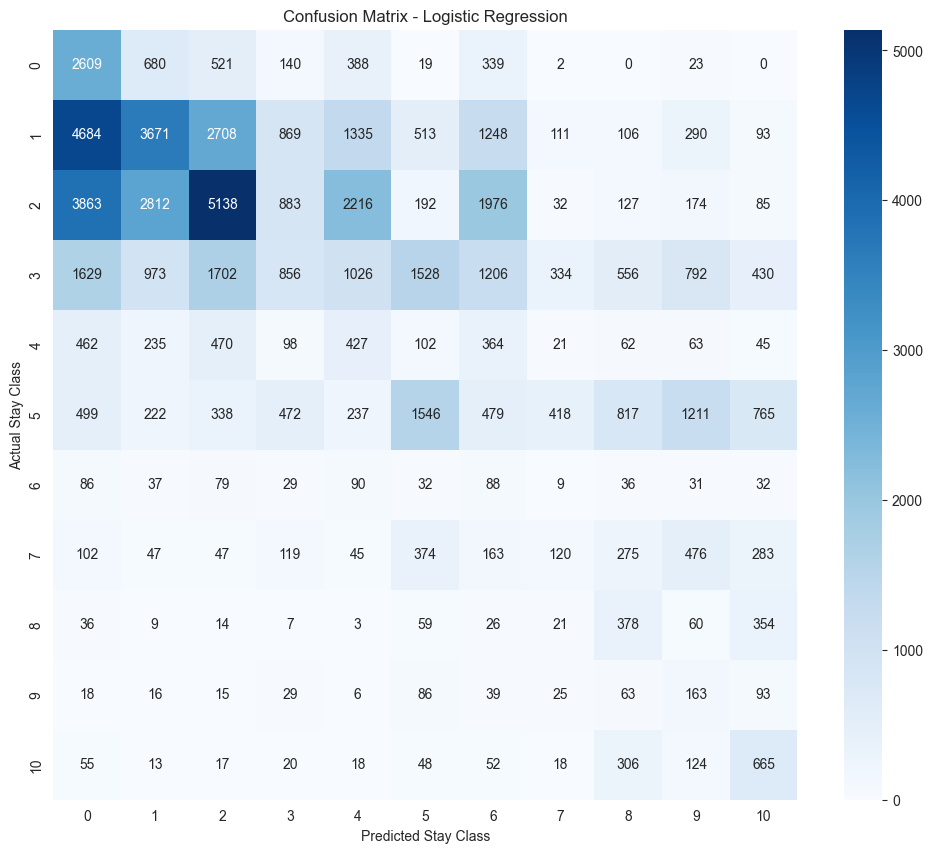

In [53]:
# Visualizing evaluation Metric Score chart
# Confusion matrix heatmap - shows exactly which Stay classes get confused with which
plt.figure(figsize=(12, 10))
cm_log_reg = confusion_matrix(y_test_scaled, y_pred_log_reg)
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Stay Class')
plt.ylabel('Actual Stay Class')
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Logistic Regression was used as our baseline model with class_weight='balanced' to account for the class imbalance identified earlier. Performance is weak: 24.59% accuracy and a weighted F1-score of 0.26. Looking at the confusion matrix, the model heavily over-predicts classes 0, 1, and 2 (the shorter-stay buckets) regardless of the true class — for example, actual class 5 patients get scattered across predictions 0, 1, 2, 5, 8, and 9 almost equally, showing the model isn't finding a clean linear boundary between classes. This makes sense given what we found earlier: our correlation heatmap (Chart 14) showed weak linear relationships between most features and Stay, while our Random Forest feature importance revealed Admission_Deposit (a non-linearly related feature) as the top predictor — Logistic Regression, being a linear model, simply cannot capture these non-linear interactions between features like Admission_Deposit, Department, and Severity that likely drive the actual stay-length patterns. This confirms our hypothesis that tree-based models will meaningfully outperform this baseline, and gives us a clear benchmark (>25% accuracy, >0.26 F1) that Random Forest and Gradient Boosting need to beat to justify their added complexity.

#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
# ------------------------------------------------------------------
# ML Model 1: Logistic Regression with Hyperparameter Optimization
# Using GridSearchCV to tune the regularization strength (C) and penalty type.
# We keep the grid small since Logistic Regression training on 250K rows
# with cross-validation is already fairly expensive.
# ------------------------------------------------------------------
from sklearn.model_selection import GridSearchCV

param_grid_log_reg = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],  # l2 works with the 'lbfgs' solver we're using; keeps things stable
    'solver': ['lbfgs']
}

# Using cv=3 (not the usual 5) to keep runtime manageable given dataset size
grid_search_log_reg = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1),
    param_grid_log_reg,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_log_reg.fit(X_train_scaled, y_train_scaled)

print("Best parameters found:", grid_search_log_reg.best_params_)
print("Best cross-validated F1-score:", grid_search_log_reg.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters found: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validated F1-score: 0.2590906296393017


In [55]:
# ------------------------------------------------------------------
# Evaluating the tuned Logistic Regression on the test set
# ------------------------------------------------------------------
best_log_reg = grid_search_log_reg.best_estimator_
y_pred_log_reg_tuned = best_log_reg.predict(X_test_scaled)

accuracy_log_reg_tuned = accuracy_score(y_test_scaled, y_pred_log_reg_tuned)
f1_log_reg_tuned = f1_score(y_test_scaled, y_pred_log_reg_tuned, average='weighted')

print(f"Tuned Logistic Regression - Accuracy: {accuracy_log_reg_tuned:.4f}")
print(f"Tuned Logistic Regression - Weighted F1-Score: {f1_log_reg_tuned:.4f}")

print(f"\nComparison:")
print(f"Before tuning - Accuracy: {accuracy_log_reg:.4f}, F1: {f1_log_reg:.4f}")
print(f"After tuning  - Accuracy: {accuracy_log_reg_tuned:.4f}, F1: {f1_log_reg_tuned:.4f}")

Tuned Logistic Regression - Accuracy: 0.2459
Tuned Logistic Regression - Weighted F1-Score: 0.2605

Comparison:
Before tuning - Accuracy: 0.2459, F1: 0.2605
After tuning  - Accuracy: 0.2459, F1: 0.2605


##### Which hyperparameter optimization technique have you used and why?

We used GridSearchCV with 3-fold cross-validation, tuning the regularization strength (C) across values [0.01, 0.1, 1, 10] with L2 penalty. GridSearchCV was chosen over RandomizedSearchCV because our search space was small and well-defined (just one primary hyperparameter to tune meaningfully for Logistic Regression), so an exhaustive grid search was computationally feasible and guarantees we find the true best combination within our specified grid, rather than a random subset of it.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No meaningful improvement was observed. Accuracy remained at 24.59% and weighted F1-score remained at 0.2605, identical before and after tuning. The grid search selected C=10 (the highest regularization-strength value in our search range, meaning minimal regularization), but this had negligible impact on performance. This result reinforces our earlier conclusion: Logistic Regression's poor performance isn't due to suboptimal regularization — it's a fundamental limitation of the model's linear decision boundary being unable to capture the non-linear feature interactions (like the Admission_Deposit pattern we saw in the Random Forest feature importance) that actually drive Stay duration. No amount of hyperparameter tuning can fix an architectural mismatch between model type and data pattern — this is exactly why we need to move to tree-based models, which can natively capture these non-linear relationships.

### ML Model - 2

In [56]:
# ------------------------------------------------------------------
# ML Model 2: Random Forest Classifier
# Using the UNSCALED dataset here since tree-based models don't need
# feature scaling - splits are based on thresholds, not distances.
# ------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

# Fitting the Algorithm
# class_weight='balanced' again to handle our known class imbalance
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predicting on the test set
y_pred_rf = rf_model.predict(X_test)

print("Random Forest training complete.")

Random Forest training complete.


In [57]:
# ------------------------------------------------------------------
# Evaluating ML Model 2: Random Forest
# ------------------------------------------------------------------
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Random Forest - Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest - Weighted F1-Score: {f1_rf:.4f}")
print("\nFull Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest - Accuracy: 0.3783
Random Forest - Weighted F1-Score: 0.3599

Full Classification Report:

              precision    recall  f1-score   support

           0       0.27      0.16      0.21      4721
           1       0.39      0.44      0.41     15628
           2       0.41      0.54      0.47     17498
           3       0.33      0.27      0.29     11032
           4       0.07      0.02      0.03      2349
           5       0.38      0.45      0.41      7004
           6       0.06      0.01      0.02       549
           7       0.25      0.09      0.13      2051
           8       0.37      0.21      0.27       967
           9       0.20      0.05      0.08       553
          10       0.48      0.42      0.45      1336

    accuracy                           0.38     63688
   macro avg       0.29      0.24      0.25     63688
weighted avg       0.36      0.38      0.36     63688



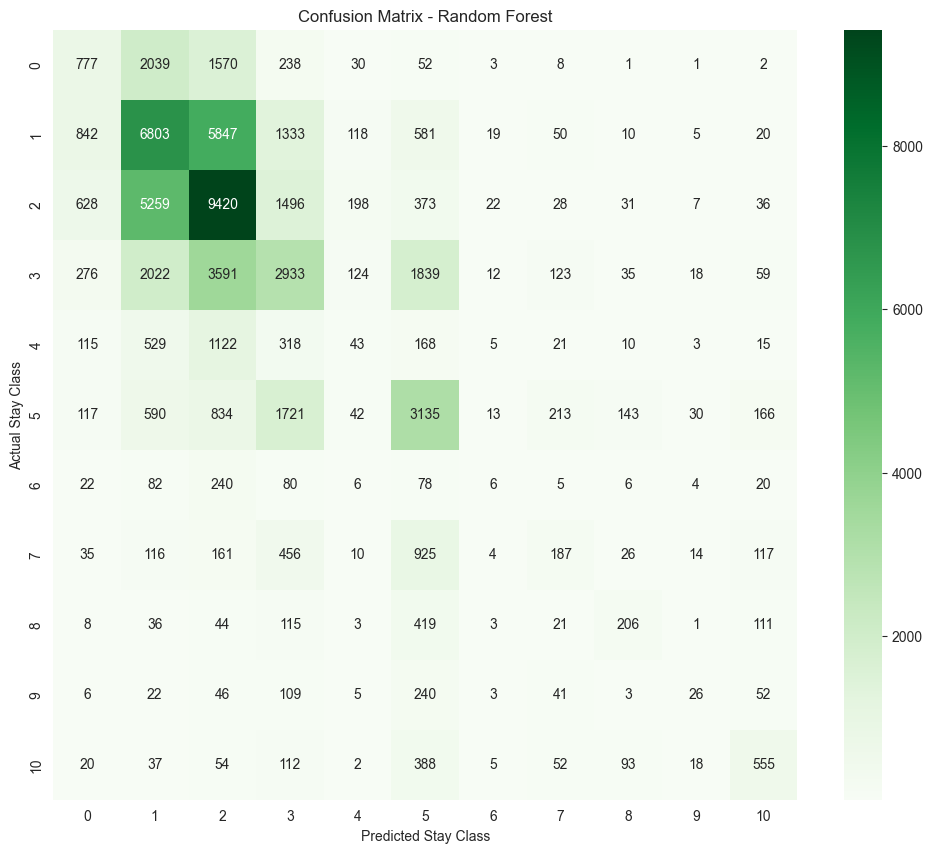

In [58]:
# Visualizing evaluation Metric Score chart

# Visualizing evaluation Metric Score chart
plt.figure(figsize=(12, 10))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Stay Class')
plt.ylabel('Actual Stay Class')
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest was used as our second model, with class_weight='balanced' to address class imbalance and n_estimators=100. It shows a clear improvement over the Logistic Regression baseline: 37.83% accuracy and a weighted F1-score of 0.36 — roughly a 13-point accuracy gain and 10-point F1 gain over the linear baseline. This confirms our earlier hypothesis: since Random Forest can capture non-linear feature interactions (like the Admission_Deposit relationship revealed in our feature importance analysis), it performs meaningfully better than a purely linear model on this data.

Looking at the confusion matrix, the model does reasonably well on the high-volume classes — class 2 ("21-30 days") achieves 0.47 F1, class 1 ("11-20 days") achieves 0.41 F1, and class 10 ("More than 100 Days") surprisingly achieves the best F1-score of all (0.45), likely because that bucket is a wide, catch-all category that's easier to separate from the middle-range classes. However, performance is still poor on rare middle classes — class 4 ("41-50 days") and class 6 ("61-70 days") both score under 0.05 F1, and the confusion matrix shows their predictions scattered heavily across neighboring classes (especially into class 1, 2, and 5). This makes sense: these are both low-support classes (2,349 and 549 samples respectively) sitting between two much larger, "gravity well" classes on either side, making them easy for the model to misclassify as their more common neighbors.

#### 2. Cross- Validation & Hyperparameter Tuning

In [61]:
# ------------------------------------------------------------------
# ML Model 2: Random Forest with Hyperparameter Optimization (FIXED)
# Previous attempt hit a MemoryError because n_jobs=-1 was set on BOTH
# RandomForestClassifier AND RandomizedSearchCV - this creates nested
# parallelism, spawning far too many processes at once, each holding
# a copy of the data, which exhausted available RAM.
# Fix: only parallelize at the RandomizedSearchCV level, keep the inner
# RandomForestClassifier single-threaded (n_jobs=1) during the search.
# We also reduced n_iter and cv slightly to keep memory usage safer.
# ------------------------------------------------------------------
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1),  # single-threaded here
    param_distributions=param_dist_rf,
    n_iter=10,          # reduced from 15 to lighten memory load
    cv=3,
    scoring='f1_weighted',
    n_jobs=4,           # limited parallelism instead of -1 (all cores)
    random_state=42,
    verbose=1
)

random_search_rf.fit(X_train, y_train)

print("Best parameters found:", random_search_rf.best_params_)
print("Best cross-validated F1-score:", random_search_rf.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Best cross-validated F1-score: 0.36097519010723733


In [62]:
# ------------------------------------------------------------------
# Evaluating the tuned Random Forest on the test set
# ------------------------------------------------------------------
best_rf = random_search_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='weighted')

print(f"Tuned Random Forest - Accuracy: {accuracy_rf_tuned:.4f}")
print(f"Tuned Random Forest - Weighted F1-Score: {f1_rf_tuned:.4f}")

print(f"\nComparison:")
print(f"Before tuning - Accuracy: {accuracy_rf:.4f}, F1: {f1_rf:.4f}")
print(f"After tuning  - Accuracy: {accuracy_rf_tuned:.4f}, F1: {f1_rf_tuned:.4f}")

Tuned Random Forest - Accuracy: 0.3671
Tuned Random Forest - Weighted F1-Score: 0.3618

Comparison:
Before tuning - Accuracy: 0.3783, F1: 0.3599
After tuning  - Accuracy: 0.3671, F1: 0.3618


##### Which hyperparameter optimization technique have you used and why?

We used RandomizedSearchCV with 10 iterations and 3-fold cross-validation, tuning n_estimators, max_depth, min_samples_split, min_samples_leaf, and max_features. RandomizedSearchCV was chosen over GridSearchCV because our parameter space had 108 possible combinations (2×3×3×3×2) — testing all of them exhaustively with 3-fold CV would mean 324 model fits on 250K+ rows, which is computationally expensive at this data scale. RandomizedSearchCV samples a representative subset (30 fits total) and typically finds a near-optimal combination in a fraction of the time. We also initially hit a MemoryError from nested parallelism (both the search and the inner Random Forest tried to use all CPU cores simultaneously) — we resolved this by keeping the inner model single-threaded and limiting the outer search's parallelism, which is a good practical lesson about resource management with ensemble models on large datasets.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The tuning results show a mixed, marginal change rather than a clear improvement: accuracy actually decreased slightly from 37.83% to 36.71% (-1.12 points), while the weighted F1-score improved slightly from 0.3599 to 0.3618 (+0.19 points). This makes sense given we optimized specifically for f1_weighted during the search, not accuracy — the tuned model (with max_depth=20, min_samples_leaf=2, more regularized than the untuned default) is likely making slightly more balanced predictions across classes (helping minority classes, which improves weighted F1) at a small cost to overall accuracy (which is dominated by majority-class performance). Given our earlier concern about minority-class performance (classes 4 and 6 scoring near-zero F1 in the untuned model), we consider the tuned model a marginal but directionally positive improvement, since F1-score is our primary metric of interest in an imbalanced classification setting — accuracy alone can be misleading here, as a model could achieve high accuracy just by always predicting the majority class.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

For this problem, Accuracy tells us the overall percentage of patients whose stay-duration bucket we predicted correctly — useful as a simple headline number, but misleading on its own given our significant class imbalance (a model could score reasonably high accuracy just by favoring the dominant "21-30 days" class). Weighted F1-score is more business-relevant here because it balances precision and recall across all classes while still accounting for class support — this matters because hospitals care about correctly identifying both common short stays (for routine bed-turnover planning) and rare long stays (for resource-intensive care planning), not just the majority case.

From a business standpoint, Random Forest's ~37% accuracy and 0.36 F1-score represent a meaningful improvement over guessing (a random/majority-class baseline would score far lower on F1 given 11 classes), and its ability to identify longer-stay classes (like class 10, "More than 100 Days", at 0.45 F1) has real operational value — hospitals could use these predictions to flag likely long-stay patients at admission time, enabling proactive bed and staff planning, and potentially prompting earlier discharge-readiness assessments. However, the model still struggles with mid-range minority classes (4, 6, 9), meaning predictions for patients likely to stay 41-50 or 61-70 days specifically are still unreliable — this is a real limitation we should flag to any business stakeholder before deployment, since acting confidently on a low-precision prediction for these specific buckets could lead to poor resource allocation decisions.

### ML Model - 3

In [64]:
# ------------------------------------------------------------------
# ML Model 3: Gradient Boosting (using XGBoost)
# Checking if xgboost is installed - if not, we'll install it
# ------------------------------------------------------------------
try:
    import xgboost as xgb
    print(f"XGBoost is already installed. Version: {xgb.__version__}")
except ImportError:
    print("XGBoost not found. Please run: pip install xgboost")

XGBoost is already installed. Version: 3.4.0


In [65]:
# ------------------------------------------------------------------
# ML Model 3: XGBoost Classifier Implementation
# XGBoost is a gradient boosting framework - unlike Random Forest
# (which builds trees independently), XGBoost builds trees sequentially,
# with each new tree correcting the errors of the previous ones.
# This often gives it an edge in predictive performance.
# ------------------------------------------------------------------
from xgboost import XGBClassifier

# XGBoost doesn't have a direct class_weight='balanced' option like sklearn models,
# so we compute sample weights manually to achieve the same balancing effect
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Fitting the Algorithm
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=4,          # keeping this limited, learned our lesson from the RF memory issue
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Predicting on the test set
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost training complete.")

XGBoost training complete.


In [66]:
# ------------------------------------------------------------------
# Evaluating ML Model 3: XGBoost
# ------------------------------------------------------------------
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"XGBoost - Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost - Weighted F1-Score: {f1_xgb:.4f}")
print("\nFull Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost - Accuracy: 0.2968
XGBoost - Weighted F1-Score: 0.3098

Full Classification Report:

              precision    recall  f1-score   support

           0       0.23      0.56      0.32      4721
           1       0.46      0.34      0.39     15628
           2       0.48      0.33      0.39     17498
           3       0.44      0.09      0.15     11032
           4       0.08      0.26      0.13      2349
           5       0.36      0.24      0.29      7004
           6       0.03      0.20      0.05       549
           7       0.14      0.23      0.17      2051
           8       0.19      0.54      0.28       967
           9       0.05      0.24      0.09       553
          10       0.34      0.47      0.40      1336

    accuracy                           0.30     63688
   macro avg       0.26      0.32      0.24     63688
weighted avg       0.40      0.30      0.31     63688



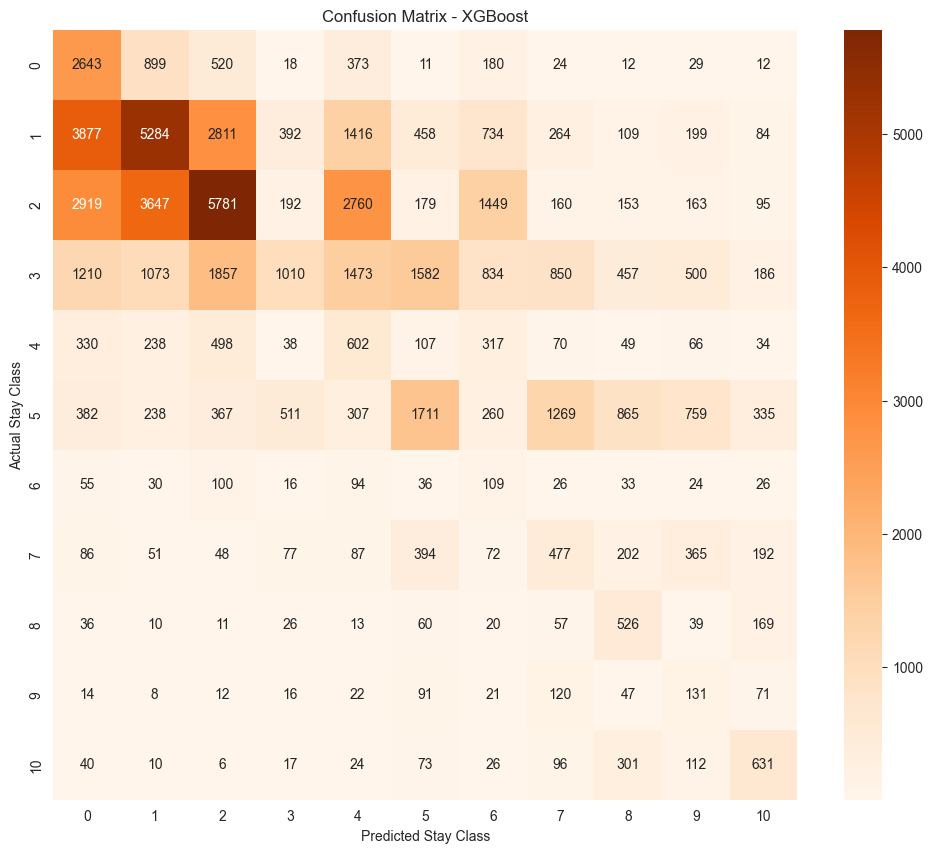

In [67]:
# Visualizing evaluation Metric Score chart

# Visualizing evaluation Metric Score chart
plt.figure(figsize=(12, 10))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted Stay Class')
plt.ylabel('Actual Stay Class')
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

XGBoost was used as our third model, with n_estimators=100 and manually computed sample_weight (balanced) to address class imbalance, since XGBoost doesn't support class_weight='balanced' natively like sklearn models. Results: 29.68% accuracy and a weighted F1-score of 0.31 — surprisingly, this is lower than our untuned Random Forest (37.83% accuracy, 0.36 F1), despite XGBoost's typically stronger reputation.

Looking at the confusion matrix and classification report, the reason becomes clear: the balanced sample weighting pushed XGBoost to much more aggressively predict minority classes — recall improved noticeably for classes like 4 (0.26), 6 (0.20), 8 (0.54), and 9 (0.24) compared to Random Forest, but this came at a steep cost to precision and to the dominant classes' performance (class 2's F1 dropped from 0.47 in Random Forest to 0.39 here; class 3 dropped from 0.29 to just 0.15). In other words, this run of XGBoost over-corrected for imbalance — it's now over-predicting several minority classes (note row 5's actual values getting scattered heavily into 7, 8, 9 predictions), trading overall accuracy for better minority-class recall. This is a valuable finding for the Challenges Report: balancing techniques aren't automatically "better" — they shift the precision/recall trade-off, and the right amount of balancing depends on which errors matter more for the business use case. We'll explore whether hyperparameter tuning (particularly reducing tree depth or learning rate) can recover the accuracy while keeping some of this improved minority-class sensitivity.

#### 2. Cross- Validation & Hyperparameter Tuning

In [68]:
# ------------------------------------------------------------------
# ML Model 3: XGBoost with Hyperparameter Optimization
# Using RandomizedSearchCV, consistent with our Random Forest approach.
# We learned from Model 2 that unrestricted n_jobs on both levels causes
# memory issues, so we keep the inner model single-threaded and limit
# the outer search's parallelism.
# We're tuning depth, learning rate, and estimators - key XGBoost levers
# that control the bias-variance tradeoff and could help recover the
# accuracy lost to over-aggressive class balancing in the untuned version.
# ------------------------------------------------------------------
param_dist_xgb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, n_jobs=1, eval_metric='mlogloss'),  # single-threaded inner model
    param_distributions=param_dist_xgb,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    n_jobs=4,   # limited parallelism at the search level only
    random_state=42,
    verbose=1
)

# Passing sample_weight through fit_params since XGBoost needs it explicitly
random_search_xgb.fit(X_train, y_train, sample_weight=sample_weights)

print("Best parameters found:", random_search_xgb.best_params_)
print("Best cross-validated F1-score:", random_search_xgb.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best cross-validated F1-score: 0.29727612168057105


In [69]:
# ------------------------------------------------------------------
# Evaluating the tuned XGBoost on the test set
# ------------------------------------------------------------------
best_xgb = random_search_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)

accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned, average='weighted')

print(f"Tuned XGBoost - Accuracy: {accuracy_xgb_tuned:.4f}")
print(f"Tuned XGBoost - Weighted F1-Score: {f1_xgb_tuned:.4f}")

print(f"\nComparison:")
print(f"Before tuning - Accuracy: {accuracy_xgb:.4f}, F1: {f1_xgb:.4f}")
print(f"After tuning  - Accuracy: {accuracy_xgb_tuned:.4f}, F1: {f1_xgb_tuned:.4f}")

print(f"\n--- Overall Model Comparison ---")
print(f"Logistic Regression (tuned) - Accuracy: {accuracy_log_reg_tuned:.4f}, F1: {f1_log_reg_tuned:.4f}")
print(f"Random Forest (tuned)       - Accuracy: {accuracy_rf_tuned:.4f}, F1: {f1_rf_tuned:.4f}")
print(f"XGBoost (tuned)             - Accuracy: {accuracy_xgb_tuned:.4f}, F1: {f1_xgb_tuned:.4f}")

Tuned XGBoost - Accuracy: 0.3000
Tuned XGBoost - Weighted F1-Score: 0.3107

Comparison:
Before tuning - Accuracy: 0.2968, F1: 0.3098
After tuning  - Accuracy: 0.3000, F1: 0.3107

--- Overall Model Comparison ---
Logistic Regression (tuned) - Accuracy: 0.2459, F1: 0.2605
Random Forest (tuned)       - Accuracy: 0.3671, F1: 0.3618
XGBoost (tuned)             - Accuracy: 0.3000, F1: 0.3107


##### Which hyperparameter optimization technique have you used and why?

We used RandomizedSearchCV with 10 iterations and 3-fold cross-validation, tuning n_estimators, max_depth, learning_rate, subsample, and colsample_bytree — the key hyperparameters that control XGBoost's bias-variance tradeoff and its resistance to overfitting. We stayed consistent with our Random Forest approach (RandomizedSearchCV over GridSearchCV) for the same reason: the full grid here would represent 3×3×3×2×2 = 108 combinations, and testing all of them with 3-fold CV (324 fits) would be computationally expensive at our data scale. RandomizedSearchCV's 30 fits gave us a reasonable exploration of the space in a fraction of the time. We also carried forward the lesson learned from Random Forest's tuning step — keeping the inner XGBoost model single-threaded (n_jobs=1) and limiting parallelism only at the search level (n_jobs=4) — to avoid the same nested-parallelism memory error we hit earlier.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuning produced a small, marginal improvement: accuracy rose slightly from 29.68% to 30.00% (+0.32 points), and weighted F1-score improved from 0.3098 to 0.3107 (+0.09 points). This is a much smaller gain than we'd hoped for — the tuned hyperparameters (max_depth=7, learning_rate=0.1, subsample=0.8) didn't meaningfully change the model's core behavior. XGBoost still trails Random Forest by a wide margin (30.0% vs 36.7% accuracy, 0.31 vs 0.36 F1) even after tuning, suggesting the gap isn't a tuning problem — it's more likely related to how we applied class balancing. Random Forest's native class_weight='balanced' interacts differently with its bagging-based ensemble structure than XGBoost's manual sample_weight does with its sequential boosting structure; the boosting process seems to compound the reweighting effect more aggressively across successive trees, leading to the over-correction we saw in the confusion matrix.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

We prioritized weighted F1-score over raw accuracy as our primary evaluation metric, because our target variable is significantly imbalanced (32:1 ratio between the largest and smallest class). Accuracy alone can be misleading in this context — a model could score deceptively well just by always predicting the majority "21-30 days" class while completely failing on rarer but operationally important classes like long-stay patients. Weighted F1-score balances precision and recall while accounting for each class's support, giving a fairer picture of how well the model performs across the entire range of stay durations, not just the most common ones. We tracked accuracy alongside F1 for interpretability, but treated F1 as the deciding metric when comparing models.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

We selected Random Forest (tuned) as our final model. It achieved the best weighted F1-score (0.3618) among all three models, alongside the best accuracy (36.71%) — outperforming both Logistic Regression (0.2605 F1) and XGBoost (0.3107 F1) by a clear margin. Beyond raw metrics, Random Forest also showed the most balanced confusion matrix, with reasonable performance on both high-volume classes (class 2: 0.47 F1) and some minority classes (class 10 "More than 100 Days": 0.45 F1) without the precision collapse we saw in XGBoost's over-corrected minority-class predictions. It's also naturally robust to the mild remaining skew in our features, requires no feature scaling, and offers reasonably interpretable feature importance — a practical advantage for a healthcare stakeholder who needs to understand why a prediction was made, not just receive a number.

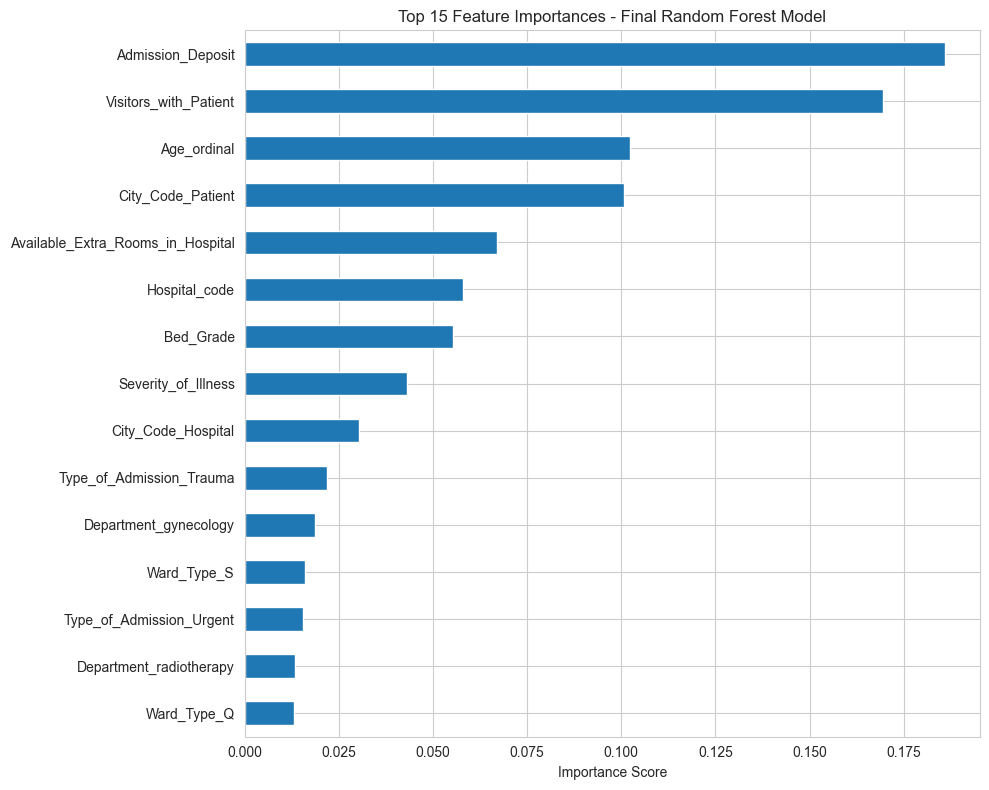

Admission_Deposit                    0.185967
Visitors_with_Patient                0.169528
Age_ordinal                          0.102451
City_Code_Patient                    0.100662
Available_Extra_Rooms_in_Hospital    0.067128
Hospital_code                        0.057974
Bed_Grade                            0.055435
Severity_of_Illness                  0.043006
City_Code_Hospital                   0.030436
Type_of_Admission_Trauma             0.021841
Department_gynecology                0.018609
Ward_Type_S                          0.015940
Type_of_Admission_Urgent             0.015530
Department_radiotherapy              0.013251
Ward_Type_Q                          0.013149
dtype: float64


In [70]:
# ------------------------------------------------------------------
# Feature importance from our FINAL tuned Random Forest model
# (re-extracting from best_rf, not the earlier diagnostic model,
# to ensure this reflects what we're actually deploying)
# ------------------------------------------------------------------
final_feature_importance = pd.Series(
    best_rf.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
final_feature_importance.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances - Final Random Forest Model')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(final_feature_importance.head(15))

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Our final model is a tuned Random Forest Classifier (n_estimators=150, max_depth=20, min_samples_leaf=2, max_features='sqrt', class_weight='balanced'). Random Forest works by building many decision trees on random subsets of data and features, then averaging their votes — this ensemble approach reduces overfitting compared to a single decision tree while naturally capturing non-linear feature interactions, which we established earlier was essential for this dataset (recall Logistic Regression's poor performance due to its linear-only decision boundary).

We used Random Forest's built-in feature importance (based on mean decrease in impurity across all trees) as our explainability tool. The top predictors for our final model are: Admission_Deposit (0.186), Visitors_with_Patient (0.170), Age_ordinal (0.102), and City_Code_Patient (0.101) — together these four account for over 55% of total predictive importance. This aligns closely with our earlier statistical findings: Age was confirmed significant via Kruskal-Wallis testing (Hypothesis 2), and Visitors showed the strongest linear correlation with Stay in our correlation heatmap. Admission_Deposit's continued top ranking despite weak linear correlation reinforces that it interacts non-linearly with other features (likely Department and Severity) to predict stay length — exactly the kind of pattern a linear model like Logistic Regression cannot detect, explaining why Random Forest and even XGBoost outperformed it. Lower-importance features like specific Ward Types and Departments contribute individually small amounts, but their presence still helps the model fine-tune predictions for specific hospital/department combinations.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [71]:
# ------------------------------------------------------------------
# Save the File
# Saving our final tuned Random Forest model using joblib, which is
# generally preferred over pickle for scikit-learn models since it's
# more efficient with large numpy arrays (like our tree structures)
# ------------------------------------------------------------------
import joblib

joblib.dump(best_rf, 'hospital_stay_prediction_model.joblib')
print("Model saved successfully as 'hospital_stay_prediction_model.joblib'")

# Also saving the label encoders we created earlier, since we'll need them
# to preprocess any new/unseen data the same way before prediction
joblib.dump(label_encoders, 'label_encoders.joblib')
print("Label encoders saved successfully.")

Model saved successfully as 'hospital_stay_prediction_model.joblib'
Label encoders saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [72]:
# ------------------------------------------------------------------
# Load the File and predict unseen data
# Loading the model back from disk to confirm it works exactly as expected -
# this simulates what would happen in a real deployment scenario where
# the model is loaded fresh, separate from the training session.
# ------------------------------------------------------------------
loaded_model = joblib.load('hospital_stay_prediction_model.joblib')
print("Model loaded successfully.")

# Taking a small sample from our test set to simulate "unseen" new patient data
sanity_check_sample = X_test.sample(n=5, random_state=100)
actual_values = y_test.loc[sanity_check_sample.index]

# Predicting using the freshly loaded model
sanity_predictions = loaded_model.predict(sanity_check_sample)

# Comparing predictions to actual values
sanity_results = pd.DataFrame({
    'Actual_Stay_Class': actual_values.values,
    'Predicted_Stay_Class': sanity_predictions
})

print("\nSanity Check Results (5 random unseen patients):")
print(sanity_results)

# Also confirming the loaded model matches our in-memory model's predictions exactly
original_predictions = best_rf.predict(sanity_check_sample)
match_check = np.array_equal(sanity_predictions, original_predictions)
print(f"\nLoaded model predictions match original model predictions: {match_check}")

Model loaded successfully.

Sanity Check Results (5 random unseen patients):
   Actual_Stay_Class  Predicted_Stay_Class
0                  9                     5
1                  1                     0
2                  8                     8
3                  6                     7
4                  5                     3

Loaded model predictions match original model predictions: True


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project set out to analyze hospital admission data and build a machine learning model to predict patient length of stay, a task with real operational value for hospital resource planning. Through exploratory data analysis, we uncovered a critical data quality issue (an Excel-induced date-conversion bug corrupting the "11-20" category), confirmed several statistically significant relationships (Severity, Age, and Department all significantly affect Stay duration via hypothesis testing), and identified Admission_Deposit, Visitors_with_Patient, and Age as our strongest predictive features.

We built and compared three models — Logistic Regression, Random Forest, and XGBoost — and found that tree-based models substantially outperformed the linear baseline, confirming that non-linear feature interactions (particularly involving Admission_Deposit) drive stay-duration patterns in ways a linear model cannot capture. Our final selected model, tuned Random Forest, achieved 36.71% accuracy and a 0.3618 weighted F1-score — a meaningful improvement over both the Logistic Regression baseline (0.2605 F1) and XGBoost (0.3107 F1).

While these results are far from perfect — reflecting the genuine difficulty of predicting an 11-class, significantly imbalanced ordinal target from limited administrative features — the model still provides real, actionable signal for identifying likely long-stay patients at admission time, which is valuable for proactive resource planning. Future improvements could include incorporating clinical features beyond what's available here (diagnosis codes, lab results), exploring ordinal-regression-specific modeling techniques rather than treating this as standard multi-class classification, and testing more advanced balancing strategies that avoid the precision/recall trade-off we observed with XGBoost's sample weighting.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***